# First import the necessary library

In [1]:
import pyspedas

from pyspedas import mms_load_fgm, mms_load_fpi
from pyspedas.mms import fgm,fpi,edp,mec #wrappers
from pyspedas import mms

import pytplot 
from pytplot import *
from pytplot import tplot
from pytplot import store_data, get_data
from pytplot import options, annotate,tplot_options
from pytplot import tlimit,highlight,timebar,time_double,time_string,time_datetime

from datetime import datetime
import numpy as np
import pandas as pd
import xarray as xr

import cdflib
import datetime,glob,os,re
from matplotlib import style,ticker
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import hvplot.xarray

In [3]:
taistarttime = '20160122071714'

In [4]:
def create_directories_if_not_exist(*paths):
    for path in paths:
        if not os.path.exists(path):
            os.makedirs(path)
# Define the file paths
file_path = os.path.join(os.getcwd(), 'Phase1a')
output_folder = os.path.join(os.getcwd(),'Plots',f"{taistarttime}")

# Call the function to create directories
create_directories_if_not_exist(file_path, output_folder)

# FPI PyTplot

In [5]:
def find(date):
    directory = os.path.join(os.getcwd(), 'Phase1a')
    # Define the pattern to match the file names
    pattern = re.compile(rf'mms([1-4])_(mec|fpi|fgm|edp)_brst_l2(?:_(des-moms|dis-moms|epht89d|dce))?_{date}_v\d+\.\d+\.\d+')

    # Initialize dictionary to store file paths
    file_paths = {'fgm': [], 'fpi': [], 'edp': []}

    # Iterate over files in the directory
    for filename in os.listdir(directory):
        # Match the filename with the pattern
        match = pattern.match(filename)
        if match:
            datatype = match.group(3) if match.group(3) else ''  # Extracting datatype, if available
             
            # Construct the full file path
            filepath = os.path.join(directory, filename)
                        
            if datatype in ['des-moms', 'dis-moms']:
                file_paths['fpi'].append(filepath)
            elif match.group(2) == 'fgm' and (datatype in ['', 'epht89d']):
                file_paths['fgm'].append(filepath)
            elif datatype == 'dce':
                file_paths['edp'].append(filepath)

    return file_paths
    
def convolve(data,window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='same')

17-Jun-24 12:03:59: C:\Users\dell\PycharmProjects\pyspedas\venv\lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(



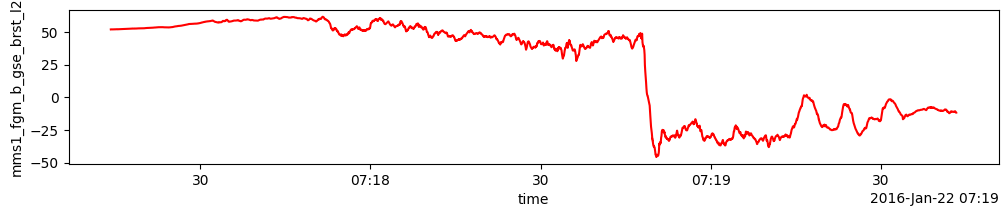

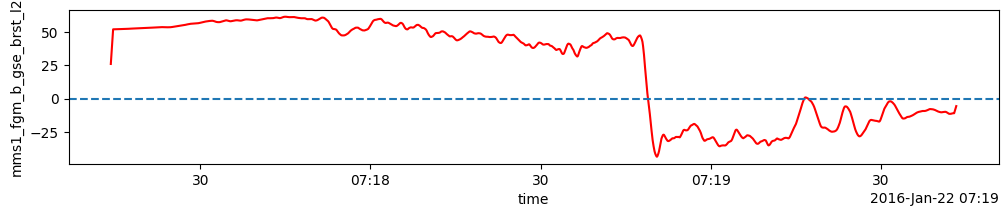

In [6]:
fgm_paths = find(f"{taistarttime}")['fgm']

b_fgm_paths =  [path for path in fgm_paths if 'fgm' in path]
num_paths_b = len(fgm_paths) # Number of elements in dis_moms_paths
paths_per_b = 4 # Number of paths to process in each iteration

# Loop through des_moms_paths and create pytplot objects
for i in range(0, num_paths_b, paths_per_b):
    paths_slice = b_fgm_paths[i:i+paths_per_b]
    bfield = pytplot.cdf_to_tplot(paths_slice)

B1 = pytplot.get_data('mms1_fgm_b_gse_brst_l2',xarray=True,dt=True)
R1 = pytplot.get_data('mms1_fgm_r_gse_brst_l2',xarray=True,dt=True).rename({'time': 'epoch'})
mms1_bdataset = xr.merge([B1,R1]).sel(epoch=~xr.merge([B1,R1]).indexes['epoch'].duplicated())
 
mms1_bdataset.mms1_fgm_b_gse_brst_l2.isel(v_dim=2).plot(figsize=(12,2),c='r')
xr.apply_ufunc(convolve,mms1_bdataset.mms1_fgm_b_gse_brst_l2.isel(v_dim=2),kwargs={'window_size': 100}).plot(figsize=(12,2),c='r')
plt.axhline(y=0,ls='--')
plt.show()

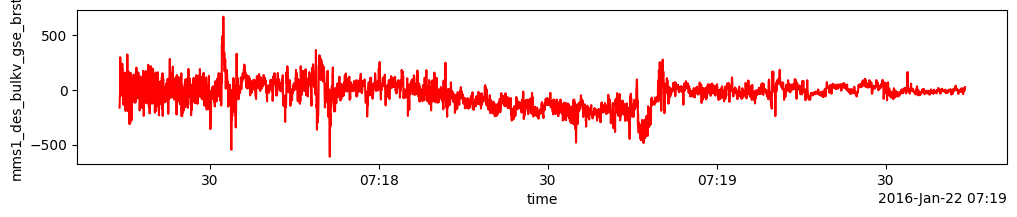

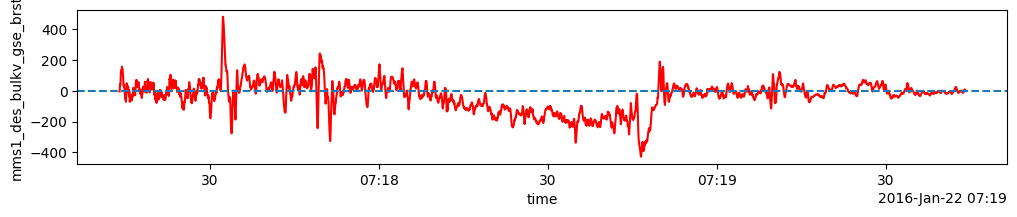

In [7]:
des_fpi_paths = find(f"{taistarttime}")['fpi']
des_moms_paths =  [path for path in des_fpi_paths if 'des-moms' in path]
num_paths_e = len(des_moms_paths) # Number of elements in dis_moms_paths
paths_per_e = 4 # Number of paths to process in each iteration

# Loop through des_moms_paths and create pytplot objects
for i in range(0, num_paths_e, paths_per_e):
    paths_slice = des_moms_paths[i:i+paths_per_e]
    efield = pytplot.cdf_to_tplot(paths_slice)

EE1 = pytplot.get_data('mms1_des_energyspectr_omni_brst',xarray=True,metadata=False,dt=True,units=True).rename({'v_dim': 'e_dim'}) 
EN1 = pytplot.get_data('mms1_des_numberdensity_brst',xarray=True,dt=True)
EV1 = pytplot.get_data('mms1_des_bulkv_gse_brst',xarray=True,dt=True)
ET1 = pytplot.get_data('mms1_des_temppara_brst',xarray=True,dt=True)
ETP1 = pytplot.get_data('mms1_des_tempperp_brst',xarray=True,dt=True)
mms1_edataset = xr.merge([EE1,EN1,EV1,ET1,ETP1])

uniform_time_series = pd.date_range(start= mms1_edataset.time.values.min(), 
                                    end= mms1_edataset.time.values.max(), 
                                    freq='30ms').tz_localize('UTC').values

mms1i_bdataset = mms1_bdataset.interp(time=uniform_time_series,method='linear',kwargs={"fill_value": "extrapolate"})
mms1i_edataset = mms1_edataset.interp_like(mms1i_bdataset,method="linear",kwargs={"fill_value": "extrapolate"}) 
mms1i_brdataset = mms1i_bdataset.interp(epoch=mms1i_bdataset.time,method="linear",kwargs={"fill_value": "extrapolate"}) 
mms1i_edataset.mms1_des_bulkv_gse_brst.isel(v_dim=2).plot(figsize=(12, 2), color='r')

# Apply the convolve function with a specific window size (e.g., 100)
xr.apply_ufunc(convolve, mms1i_edataset.mms1_des_bulkv_gse_brst.isel(v_dim=2), kwargs={'window_size': 10}).plot(figsize=(12, 2), color='r')

# Add a horizontal line at y=0
plt.axhline(y=0, linestyle='--')
plt.show()                            

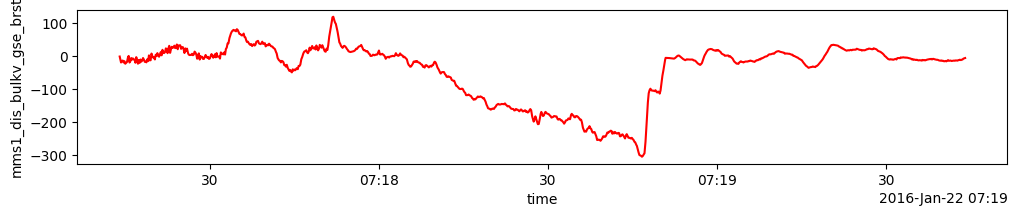

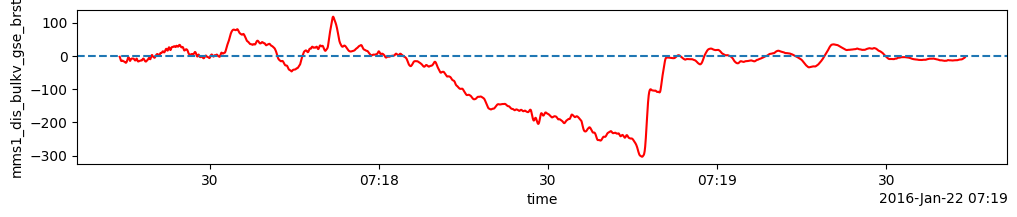

In [8]:
dis_fpi_paths = find(f"{taistarttime}")['fpi']
dis_moms_paths =  [path for path in dis_fpi_paths if 'dis-moms' in path]
num_paths_i = len(dis_moms_paths) # Number of elements in dis_moms_paths
paths_per_i = 4 # Number of paths to process in each iteration

# Loop through dis_moms_paths and create pytplot objects
for i in range(0, num_paths_i, paths_per_i):
    paths_slice = dis_moms_paths[i:i+paths_per_i]
    ion = pytplot.cdf_to_tplot(paths_slice)
    
IE1 = pytplot.get_data('mms1_dis_energyspectr_omni_brst',xarray=True,metadata=False,dt=True,units=True).rename({'v_dim': 'e_dim'})
IN1 = pytplot.get_data('mms1_dis_numberdensity_brst',xarray=True,metadata=False,dt=True,units=True)
IV1 = pytplot.get_data('mms1_dis_bulkv_gse_brst',xarray=True,metadata=False,dt=True,units=True)
IT1 = pytplot.get_data('mms1_dis_temppara_brst',xarray=True,metadata=False,dt=True,units=True)
ITP1 = pytplot.get_data('mms1_dis_tempperp_brst',xarray=True,metadata=False,dt=True,units=True)
mms1_idataset = xr.merge([IE1,IN1,IV1,IT1,ITP1])
mms1i_idataset = mms1_idataset.interp_like(mms1i_bdataset.time,method='linear', kwargs={"fill_value": "extrapolate"}) 
                                                    
mms1i_idataset.mms1_dis_bulkv_gse_brst.isel(v_dim=2).plot(figsize=(12, 2), color='r')

# Apply the convolve function with a specific window size (e.g., 100)
xr.apply_ufunc(convolve, mms1i_idataset.mms1_dis_bulkv_gse_brst.isel(v_dim=2), kwargs={'window_size': 10}).plot(figsize=(12, 2), color='r')

# Add a horizontal line at y=0
plt.axhline(y=0, linestyle='--')
plt.show()                                                    

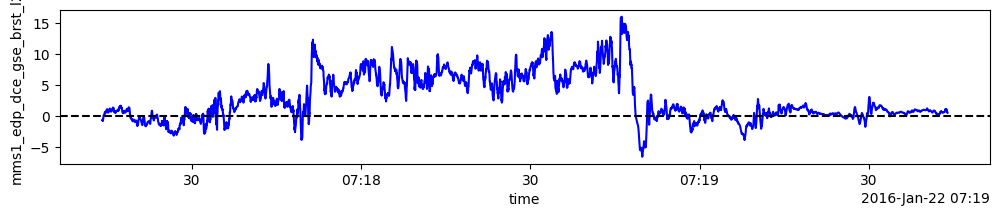

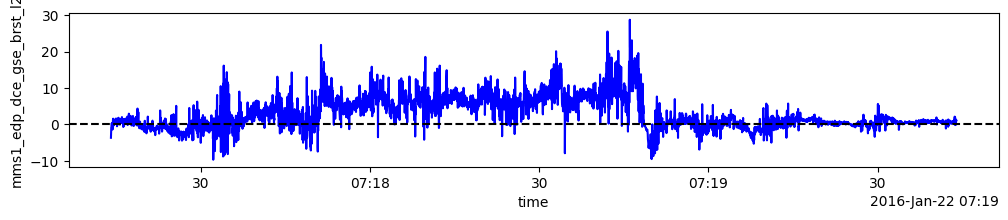

In [9]:
edp_paths = find(f"{taistarttime}")['edp']
E_edp_paths =  [path for path in edp_paths if 'edp' in path]
num_paths_E = len(edp_paths) # Number of elements in dis_moms_paths
paths_per_E = 4 # Number of paths to process in each iteration

# Loop through des_moms_paths and create pytplot objects
for i in range(0, num_paths_E, paths_per_E):
    paths_slice = E_edp_paths[i:i+paths_per_E]
    efield = pytplot.cdf_to_tplot(paths_slice)

mms1_Edataset = pytplot.get_data('mms1_edp_dce_gse_brst_l2',xarray=True,dt=True)
mms1i_Edataset = mms1_Edataset.interp_like(mms1i_edataset,method='linear', kwargs={"fill_value": "extrapolate"}) 

xr.apply_ufunc(convolve, mms1i_Edataset.isel(v_dim=0), kwargs={'window_size': 10}).plot(figsize=(12, 2), color='b')
plt.axhline(y=0, ls='--',c='k')
mms1i_Edataset.isel(v_dim=0).plot(figsize=(12,2),c='b')
# Add a horizontal line at y=0
plt.axhline(y=0, ls='--',c='k')
plt.show()

In [10]:

MID= mms1i_bdataset.mms1_fgm_b_gse_brst_l2.isel(v_dim=2)
# Assuming 'dataset' is your xarray dataset and 'variable' is the variable within it


# Calculate the sign of the variable
sign_variable = np.sign(MID)


# Find where sign changes occur
sign_change_indices = np.where((sign_variable.shift(time=-1) * sign_variable) < 0)


# Infer timestamps corresponding to sign changes
Bz = MID.time[sign_change_indices]


Bz,sign_change_indices

(<xarray.DataArray 'time' (time: 3)> Size: 24B
 array(['2016-01-22T07:18:48.876751000', '2016-01-22T07:19:16.296751000',
        '2016-01-22T07:19:17.046751000'], dtype='datetime64[ns]')
 Coordinates:
   * time     (time) datetime64[ns] 24B 2016-01-22T07:18:48.876751 ... 2016-01...,
 (array([3162, 4076, 4101], dtype=int64),))

In [11]:
def find(dataset, v_dim=None, time_slice=None):
  
    if v_dim is not None:
        variable = dataset.sel(v_dim=v_dim)

    # Calculate the sign of the variable
    sign_variable = np.sign(variable)
    
    # Find where sign changes occur
    crossing = np.where((sign_variable.shift(time=-1) * sign_variable) < 0)
    
    # Infer timestamps corresponding to sign changes
    Bz = variable.time[crossing]
    
    return Bz[0], crossing[0][0]
    
    

# Example usage:
# Assuming 'mms1i_bdataset' is your xarray datase
Bz, first_crossing_index = find(mms1i_bdataset.mms1_fgm_b_gse_brst_l2, v_dim=2, time_slice=slice(None))

print("Timestamps where sign changes occur:", Bz.values)
print("First crossing index:", first_crossing_index)

Timestamps where sign changes occur: 2016-01-22T07:18:48.876751000
First crossing index: 3162


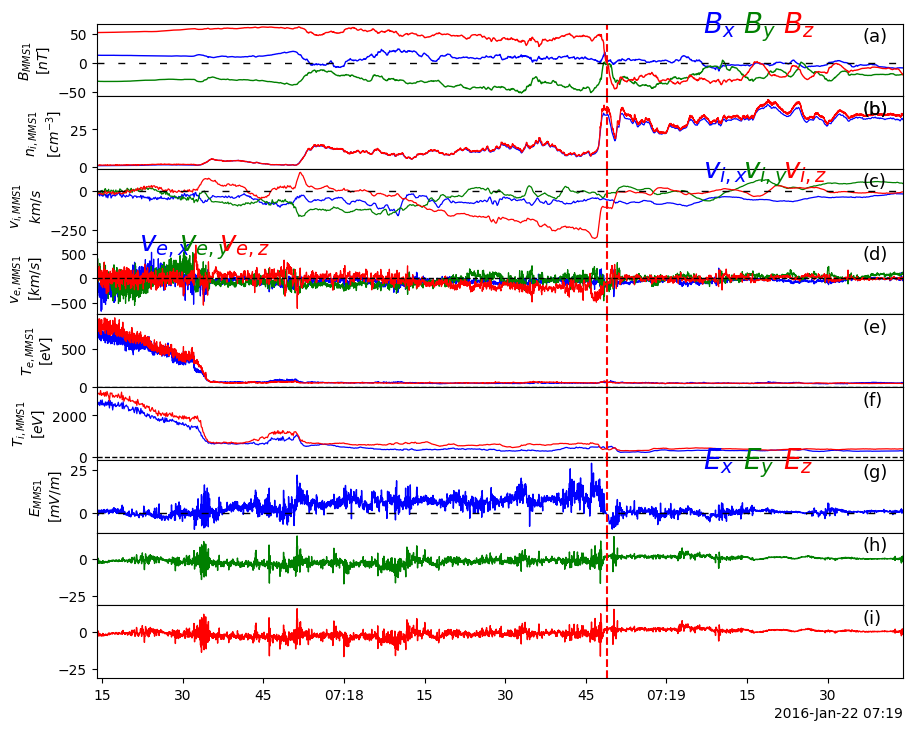

In [12]:
plt.style.use('default')

fig, axs = plt.subplots(9, 1, figsize=[10.4, 8.5], sharex=True, gridspec_kw={'hspace': 0})

# Plot data on the subplots
axs[0].text(0.95,0.95, '(a)', transform=axs[0].transAxes, fontsize=13, va='top') 
axs[1].text(0.95,0.95, '(b)', transform=axs[1].transAxes, fontsize=13, va='top') 
axs[2].text(0.95,0.95, '(c)', transform=axs[2].transAxes, fontsize=13, va='top') 
axs[3].text(0.95,0.95, '(d)', transform=axs[3].transAxes, fontsize=13, va='top') 
axs[4].text(0.95,0.95, '(e)', transform=axs[4].transAxes, fontsize=13, va='top') 
axs[5].text(0.95,0.95, '(f)', transform=axs[5].transAxes, fontsize=13, va='top') 
axs[6].text(0.95,0.95, '(g)', transform=axs[6].transAxes, fontsize=13, va='top') 
axs[7].text(0.95,0.95, '(h)', transform=axs[7].transAxes, fontsize=13, va='top')
axs[8].text(0.95,0.95, '(i)', transform=axs[8].transAxes, fontsize=13, va='top')

axs[0].plot(mms1i_bdataset.time.sel(time=slice(None)), mms1i_bdataset.mms1_fgm_b_gse_brst_l2.sel(v_dim=0), c='b', lw=1,label='Bx')
axs[0].plot(mms1i_bdataset.time.sel(time=slice(None)), mms1i_bdataset.mms1_fgm_b_gse_brst_l2.sel(v_dim=1), c='g', lw=1,label='By')
axs[0].plot(mms1i_bdataset.time.sel(time=slice(None)), mms1i_bdataset.mms1_fgm_b_gse_brst_l2.sel(v_dim=2), c='r', lw=1,label='Bz')
axs[0].axhline(y=0, c='k', ls=(0, (5, 10)), lw=1)
axs[0].annotate(r'$\mathit{B_x}$', xy=(0.75, 0.9), xycoords='axes fraction', style='italic',
                fontsize=20, color='b', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axs[0].annotate(r'$\mathit{B_y}$', xy=(0.80, 0.9), xycoords='axes fraction', style='italic',
                fontsize=20, color='g', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axs[0].annotate(r'$\mathit{B_z}$', xy=(0.85, 0.9), xycoords='axes fraction', style='italic',
                fontsize=20, color='r', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red
axs[0].set_xlim(mms1i_bdataset.time[0],mms1i_bdataset.time[-1])
#axs[0].axvspan(timestamps_of_sign_changes.time[0].values,timestamps_of_sign_changes.time[1].values, color='yellow', alpha=0.5)  # highlight the region 
axs[0].set_ylabel(r'$\mathbf{\mathit{B_{MMS1}}}$' + '\n' + r'$\mathit{[nT]}$', fontsize=10)
axs[0].yaxis.label.set_size(10)


axs[1].plot(mms1i_idataset.time, mms1i_idataset.mms1_dis_numberdensity_brst, c='b', lw=0.9)
axs[1].plot(mms1i_edataset.time, mms1i_edataset.mms1_des_numberdensity_brst, c='r', lw=0.9)
axs[1].text(0.95,0.95, '(b)', transform=axs[1].transAxes, fontsize=13, va='top')
axs[1].set_ylabel(r'$\mathbf{\mathit{n_{i,MMS1}}}$' + '\n' + r'$\mathit{[cm^{-3}]}$', fontsize=10)
axs[1].yaxis.label.set_size(10)
axs[1].set_xlim(mms1i_idataset.time[0],mms1i_idataset.time[-1])

axs[2].plot(mms1i_idataset.time, mms1i_idataset.mms1_dis_bulkv_gse_brst.sel(v_dim=0), c='b', lw=0.9,label='Vi,x')
axs[2].plot(mms1i_idataset.time, mms1i_idataset.mms1_dis_bulkv_gse_brst.sel(v_dim=1), c='g', lw=0.9,label='Vi,y')
axs[2].plot(mms1i_idataset.time, mms1i_idataset.mms1_dis_bulkv_gse_brst.sel(v_dim=2), c='r', lw=0.9,label='Vi,z')
axs[2].axhline(y=0, c='k',  ls=(0, (5, 10)), lw=1)
axs[2].annotate(r'$\mathit{v_{i,x}}$', xy=(0.75, 0.9), xycoords='axes fraction', style='italic',
                fontsize=20, color='b', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axs[2].annotate(r'$\mathit{v_{i,y}}$', xy=(0.80, 0.9), xycoords='axes fraction', style='italic',
                fontsize=20, color='g', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axs[2].annotate(r'$\mathit{v_{i,z}}$', xy=(0.85, 0.9), xycoords='axes fraction', style='italic',
                fontsize=20, color='r', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red
#axs[2].axvspan(timestamps_of_sign_changes.time[0].values,timestamps_of_sign_changes.time[1].values, color='yellow', alpha=0.5)  # highlight the region 
axs[2].set_ylabel(r'$\mathbf{\mathit{v_{i,MMS1}}}$' + '\n' + r'$\mathit{km/s}$', fontsize=10)
axs[2].set_xlim(mms1i_idataset.time[0],mms1i_idataset.time[-1])

axs[3].plot(mms1i_idataset.time.sel(time=slice(None)), mms1i_edataset.mms1_des_bulkv_gse_brst.sel(v_dim=0).sel(time=slice(None)), c='b', lw=0.9,label='Vi,x')
axs[3].plot(mms1i_edataset.time.sel(time=slice(None)), mms1i_edataset.mms1_des_bulkv_gse_brst.sel(v_dim=1).sel(time=slice(None)), c='g', lw=0.9,label='Vi,y')
axs[3].plot(mms1i_edataset.time.sel(time=slice(None)), mms1i_edataset.mms1_des_bulkv_gse_brst.sel(v_dim=2).sel(time=slice(None)), c='r', lw=0.9,label='Vi,z')
axs[3].axhline(y=0, c='k', ls='--', lw=1)
axs[3].annotate(r'$\mathit{v_{e,x}}$', xy=(0.05, 0.9), xycoords='axes fraction', style='italic',
                fontsize=20, color='b', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axs[3].annotate(r'$\mathit{v_{e,y}}$', xy=(0.10, 0.9), xycoords='axes fraction', style='italic',
                fontsize=20, color='g', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axs[3].annotate(r'$\mathit{v_{e,z}}$', xy=(0.15, 0.9), xycoords='axes fraction', style='italic',
                fontsize=20, color='r', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red
axs[3].set_ylabel(r"$\mathbf{\mathit{v_{e,MMS1}}}$" + '\n' + r"$[\mathit{km/s}]$", fontsize=10)

axs[4].plot(mms1i_edataset.time.sel(time=slice(None)), mms1i_edataset.mms1_des_temppara_brst.sel(time=slice(None)), c='b', lw=0.9,label='Te,par')
axs[4].plot(mms1i_edataset.time.sel(time=slice(None)), mms1i_edataset.mms1_des_tempperp_brst.sel(time=slice(None)), c='r', lw=0.9,label='Te,per')

axs[4].axhline(y=0, c='k', ls='--', lw=1)
axs[4].set_ylabel(r"$\mathbf{\mathit{T_{e,MMS1}}}$" + '\n' + r"$[\mathit{eV}]$", fontsize=10)

axs[5].plot(mms1i_idataset.time.sel(time=slice(None)), mms1i_idataset.mms1_dis_temppara_brst.sel(time=slice(None)), c='b', lw=0.9,label='Ti,par')
axs[5].plot(mms1i_idataset.time.sel(time=slice(None)), mms1i_idataset.mms1_dis_tempperp_brst.sel(time=slice(None)), c='r', lw=0.9,label='Ti,per')
axs[5].axhline(y=0, c='k', ls='--', lw=1)
axs[5].set_ylabel(r"$\mathbf{\mathit{T_{i,MMS1}}}$" + '\n' + r"$[\mathit{eV}]$", fontsize=10)


axs[6].plot(mms1i_Edataset.time.sel(time=slice(None)), mms1i_Edataset.isel(v_dim=0), c='b', lw=1,label='Bx')
# axs[6].plot(mms2i_Edataset.time.sel(time=slice(None)), mms2i_Edataset.sel(v_dim=1), c='g', lw=1,label='By')
# axs[6].plot(mms2i_Edataset.time.sel(time=slice(None)), mms2i_Edataset.sel(v_dim=2), c='r', lw=1,label='Bz')
axs[6].axhline(y=0, c='k', ls=(0, (5, 10)), lw=1)
axs[6].annotate(r'$\mathit{E_x}$', xy=(0.75, 0.9), xycoords='axes fraction', style='italic',
                fontsize=20, color='b', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axs[6].annotate(r'$\mathit{E_y}$', xy=(0.80, 0.9), xycoords='axes fraction', style='italic',
                fontsize=20, color='g', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axs[6].annotate(r'$\mathit{E_z}$', xy=(0.85, 0.9), xycoords='axes fraction', style='italic',
                fontsize=20, color='r', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red
axs[6].set_xlim(mms1i_bdataset.time[0],mms1i_bdataset.time[-1])
#axs[0].axvspan(timestamps_of_sign_changes.time[0].values,timestamps_of_sign_changes.time[1].values, color='yellow', alpha=0.5)  # highlight the region 
axs[6].set_ylabel(r'$\mathbf{\mathit{E_{MMS1}}}$' + '\n' + r'$\mathit{[mV/m]}$', fontsize=10)
axs[6].yaxis.label.set_size(10)
axs[7].plot(mms1i_Edataset.time.sel(time=slice(None)), mms1i_Edataset.isel(v_dim=1), c='g', lw=1,label='Bx')
axs[8].plot(mms1i_Edataset.time.sel(time=slice(None)), mms1i_Edataset.isel(v_dim=1), c='r', lw=1,label='Bx')
for ax in axs:
    ax.axvline(Bz.values,ls='--',c='r') #value obtained form below,change to MP crossing timestamp accordingly
plt.savefig(os.path.join(output_folder, f"{taistarttime}_a.png"), dpi=100)
plt.show()

In [13]:
mms1i_bdataset.time.isel(time=0).values,mms1i_bdataset.time.isel(time=-1).values

(numpy.datetime64('2016-01-22T07:17:14.016751000'),
 numpy.datetime64('2016-01-22T07:19:43.986751000'))

In [14]:
[del3,del4]= ['2016-01-22T07:17:18','2016-01-22T07:19:15']

setting timestamps

In [15]:
# Assuming 'dataset' is your xarray dataset and 'variable' is the variable within it
variable = mms1i_bdataset.mms1_fgm_b_gse_brst_l2.sel(v_dim=2, time=slice(del3,del4))

# Find where the variable crosses zero
zero_crossing = np.where(np.diff(np.sign(variable)))[0]

time_before = variable.time.isel(time=zero_crossing[0])
time_after = variable.time.isel(time=zero_crossing[0] + 1)
value_before = variable.isel(time=zero_crossing[0])
value_after = variable.isel(time=zero_crossing[0] + 1)
 # Convert datetime values to seconds since the epoch (float64)
time_before_sec = (time_before - np.datetime64('1970-01-01T00:00:00')) / np.timedelta64(1, 's')
time_after_sec = (time_after - np.datetime64('1970-01-01T00:00:00')) / np.timedelta64(1, 's')

    # Linear interpolation to find the time when the variable crosses zero
time_zero_crossing_sec = np.interp(0, [value_before, value_after], [time_before_sec, time_after_sec])

Bzt = np.datetime64(int(time_zero_crossing_sec*10**9),'ns')

time_before.values,Bzt,time_after.values

(numpy.datetime64('2016-01-22T07:18:48.876751000'),
 numpy.datetime64('2016-01-22T07:18:48.906750976'),
 numpy.datetime64('2016-01-22T07:18:48.906751000'))

In [16]:
# Custom formatting function
def format_tick_label(tick_time):
    if tick_time == major_ticks[0]:
        return f"UT\n {np.datetime_as_string(tick_time, unit='s')[11:]}"
    else:
        return np.datetime_as_string(tick_time, unit='s')[17:]
        
# Generate ticks at regular intervals for major ticks
major_interval = np.timedelta64(2, 's')  # Set interval to 1 second, adjust as needed
start_time = np.datetime64(del3)
plot_date = np.datetime_as_string(start_time, unit='D')
end_time = np.datetime64(del4)
major_ticks = np.arange(start_time, end_time + major_interval, major_interval)
# Generate ticks at regular intervals for minor ticks
minor_interval = np.timedelta64(200, 'ms')  # Set interval to 100 milliseconds, adjust as needed
minor_ticks = np.arange(start_time, end_time, minor_interval)

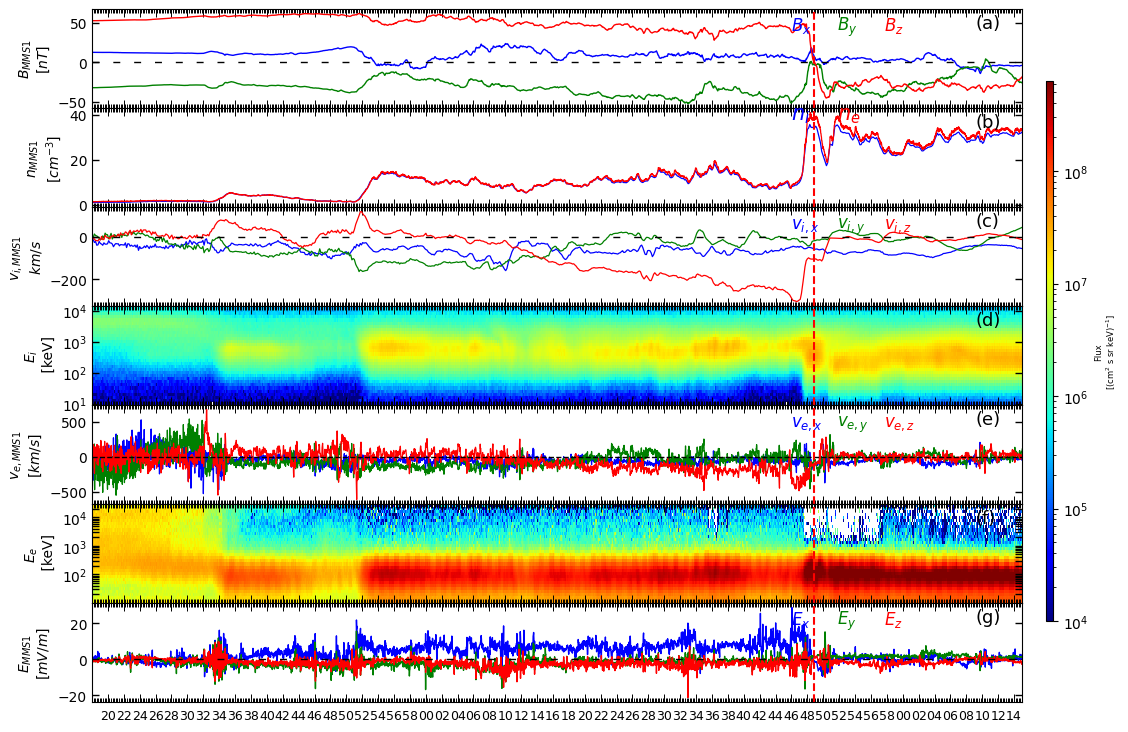

In [17]:
plt.style.use('default')

figh, axsh = plt.subplots(7, 1, figsize=[12, 9], sharex=True, gridspec_kw={'hspace': 0})

axsh[0].plot(mms1i_bdataset.time.sel(time=slice(del3,del4)), mms1i_bdataset.mms1_fgm_b_gse_brst_l2.sel(time=slice(del3,del4),v_dim=0), c='b', lw=1,label='Bx')
axsh[0].plot(mms1i_bdataset.time.sel(time=slice(del3,del4)), mms1i_bdataset.mms1_fgm_b_gse_brst_l2.sel(time=slice(del3,del4),v_dim=1), c='g', lw=1,label='By')
axsh[0].plot(mms1i_bdataset.time.sel(time=slice(del3,del4)), mms1i_bdataset.mms1_fgm_b_gse_brst_l2.sel(time=slice(del3,del4),v_dim=2), c='r', lw=1,label='Bz')
axsh[0].axhline(y=0, c='k', ls=(0, (5, 10)), lw=1)
axsh[0].text(0.95,0.95, '(a)', transform=axsh[0].transAxes, fontsize=13, va='top')
axsh[0].annotate(r'$\mathit{B_x}$', xy=(0.75, 0.8), xycoords='axes fraction', style='italic',
                fontsize=12, color='b', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axsh[0].annotate(r'$\mathit{B_y}$', xy=(0.80, 0.8), xycoords='axes fraction', style='italic',
                fontsize=12, color='g', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axsh[0].annotate(r'$\mathit{B_z}$', xy=(0.85, 0.8), xycoords='axes fraction', style='italic',
                fontsize=12, color='r', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red
axsh[0].set_xlim(mms1i_bdataset.time.sel(time=slice(del3,del4))[0],mms1i_bdataset.time.sel(time=slice(del3,del4))[-1])
axsh[0].set_ylabel(r'$\mathbf{\mathit{B_{MMS1}}}$' + '\n' + r'$\mathit{[nT]}$', fontsize=10)


axsh[1].plot(mms1i_idataset.time.sel(time=slice(del3,del4)), 
            mms1i_idataset.mms1_dis_numberdensity_brst.sel(time=slice(del3,del4)), c='b', lw=0.9)
axsh[1].plot(mms1i_edataset.time.sel(time=slice(del3,del4)), 
            mms1i_edataset.mms1_des_numberdensity_brst.sel(time=slice(del3,del4)), c='r', lw=0.9) 
axsh[1].set_ylabel(r'$\mathbf{\mathit{n_{MMS1}}}$' + '\n' + r'$\mathit{[cm^{-3}]}$', fontsize=10)
axsh[1].text(0.95,0.95, '(b)', transform=axsh[1].transAxes, fontsize=13, va='top')
axsh[1].set_xlim(mms1i_idataset.time.sel(time=slice(del3,del4))[0],
                mms1i_idataset.time.sel(time=slice(del3,del4))[-1])
axsh[1].annotate(r'$\mathit{n_i}$', xy=(0.75, 0.9), xycoords='axes fraction', style='italic',
                fontsize=15, color='b', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axsh[1].annotate(r'$\mathit{n_e}$', xy=(0.80, 0.9), xycoords='axes fraction', style='italic',fontsize=15, color='red', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green

axsh[2].plot(mms1i_idataset.time.sel(time=slice(del3,del4)), 
            mms1i_idataset.mms1_dis_bulkv_gse_brst.sel(time=slice(del3,del4)).sel(v_dim=0), c='b', lw=0.9)
axsh[2].plot(mms1i_idataset.time.sel(time=slice(del3,del4)), 
            mms1i_idataset.mms1_dis_bulkv_gse_brst.sel(time=slice(del3,del4)).sel(v_dim=1), c='g', lw=0.9)
axsh[2].plot(mms1i_idataset.time.sel(time=slice(del3,del4)), 
            mms1i_idataset.mms1_dis_bulkv_gse_brst.sel(time=slice(del3,del4)).sel(v_dim=2), c='r', lw=0.9)
axsh[2].set_xlim(mms1i_idataset.time.sel(time=slice(del3,del4))[0],
                mms1i_idataset.time.sel(time=slice(del3,del4))[-1])
axsh[2].set_ylabel(r'$\mathbf{\mathit{v_{i,MMS1}}}$' + '\n' + r'$\mathit{km/s}$', fontsize=10)
axsh[2].text(0.95,0.95, '(c)', transform=axsh[2].transAxes, fontsize=13, va='top')
axsh[2].axhline(y=0, c='k',  ls=(0, (5, 10)), lw=1)
axsh[2].annotate(r'$\mathit{v_{i,x}}$', xy=(0.75, 0.8), xycoords='axes fraction', style='italic',
                fontsize=12, color='b', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axsh[2].annotate(r'$\mathit{v_{i,y}}$', xy=(0.80, 0.8), xycoords='axes fraction', style='italic',
                fontsize=12, color='g', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axsh[2].annotate(r'$\mathit{v_{i,z}}$', xy=(0.85, 0.8), xycoords='axes fraction', style='italic',
                fontsize=12, color='r', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red
#axs[2].axvspan(timestamps_of_sign_changes.time[0].values,timestamps_of_sign_changes.time[1].values, color='yellow', alpha=0.5)  # highlight the region 
axsh[2].set_ylabel(r'$\mathbf{\mathit{v_{i,MMS1}}}$' + '\n' + r'$\mathit{km/s}$', fontsize=10)



# Plot using pcolormesh with LogNorm
pcmi = axsh[3].pcolormesh(mms1i_idataset.mms1_dis_energyspectr_omni_brst.time.sel(time=slice(del3,del4)),
                     mms1i_idataset.mms1_dis_energyspectr_omni_brst.spec_bins.sel(time=slice(del3,del4)).e_dim,
                     mms1i_idataset.mms1_dis_energyspectr_omni_brst.sel(time=slice(del3,del4)).T, cmap='jet',
                     norm=mcolors.LogNorm(vmin=1e4, vmax=1e8 * 10 ** 0.8), rasterized=True, shading="auto")

axsh[3].set_ylabel("$E_{i}$ \n [keV]")

# Set y-axis ticks as powers of 10
ticks = [f'$10^{{{int(np.log10(value))}}}$' if value > 0 else '0' for value in
         mms1i_edataset.mms1_des_energyspectr_omni_brst.spec_bins.sel(time=slice(del3,del4), e_dim=[0, 10, 20, 30])[0]]
axsh[3].set_yticks([0, 10, 20, 30], ticks)
axsh[3].text(0.95,0.95, '(d)', transform=axsh[3].transAxes, fontsize=13, va='top')

axsh[4].plot(mms1i_edataset.time.sel(time=slice(del3,del4)), mms1i_edataset.mms1_des_bulkv_gse_brst.sel(v_dim=0).sel(time=slice(del3,del4)), c='b', lw=0.9,label='Vi,x')
axsh[4].plot(mms1i_edataset.time.sel(time=slice(del3,del4)), mms1i_edataset.mms1_des_bulkv_gse_brst.sel(v_dim=1).sel(time=slice(del3,del4)), c='g', lw=0.9,label='Vi,y')
axsh[4].plot(mms1i_edataset.time.sel(time=slice(del3,del4)), mms1i_edataset.mms1_des_bulkv_gse_brst.sel(v_dim=2).sel(time=slice(del3,del4)), c='r', lw=0.9,label='Vi,z')
axsh[4].axhline(y=0, c='k', ls='--', lw=1)
axsh[4].text(0.95,0.95, '(e)', transform=axsh[4].transAxes, fontsize=13, va='top')
axsh[4].annotate(r'$\mathit{v_{e,x}}$', xy=(0.75, 0.8), xycoords='axes fraction', style='italic',
                fontsize=12, color='b', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axsh[4].annotate(r'$\mathit{v_{e,y}}$', xy=(0.80, 0.8), xycoords='axes fraction', style='italic',
                fontsize=12, color='g', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axsh[4].annotate(r'$\mathit{v_{e,z}}$', xy=(0.85, 0.8), xycoords='axes fraction', style='italic',
                fontsize=12, color='r', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red
axsh[4].set_ylabel(r"$\mathbf{\mathit{v_{e,MMS1}}}$" + '\n' + r"$[\mathit{km/s}]$", fontsize=10)


# Plot using pcolormesh with LogNorm
pcme = axsh[5].pcolormesh(mms1i_edataset.mms1_des_energyspectr_omni_brst.time.sel(time=slice(del3,del4)),
                     mms1i_edataset.mms1_des_energyspectr_omni_brst.spec_bins.sel(time=slice(del3,del4)).mean(dim='time'),
                     mms1i_edataset.mms1_des_energyspectr_omni_brst.sel(time=slice(del3,del4)).T, cmap='jet',
                     norm=mcolors.LogNorm(vmin=1e4, vmax=1e8 * 10 ** 0.8), rasterized=True, shading="auto")

axsh[5].set_ylabel("$E_{e}$ \n [keV]")
axsh[5].set_yscale('log')
axsh[5].text(0.95,0.95, '(f)', transform=axsh[5].transAxes, fontsize=13, va='top')
# Create a new axis for the colorbar
cbar_ax = plt.axes([0.92, 0.2, 0.006, 0.6])  #  
# 92% of the width of the figure from the left edge.
#10% of the height of the figure from the bottom edge.
#2% of the width of the figure.
#80% of the height of the figure
# Add colorbar
cbar = plt.colorbar(pcme, cax=cbar_ax)
cbar.set_label("Flux" + "\n" + "[(cm$^2$ s sr keV)$^{-1}$]", fontsize=6)

for ax in axsh:
    ax.tick_params(axis='both', which='major', direction='in',top=True,right=True,
                 width=1, length=5,labelsize=10)  # Adjust width and length as needed
    ax.tick_params(axis='both', which='minor', direction='in',top=True,right=True, 
                   width=1, length=5,labelsize=10)
    # Set major x-axis ticks
    ax.set_xticks(major_ticks)

    # Set minor x-axis ticks
    ax.set_xticks(minor_ticks, minor=True)

    # Format x-axis tick labels using the custom function
    formatted_major_ticks = [format_tick_label(t) for t in major_ticks]
    ax.set_xticklabels(formatted_major_ticks, rotation=0, fontsize=12)
    ax.tick_params(axis='x', which='major', labelsize=9,size=6,width=0.7,pad=5,direction='in',top=True,bottom=True)
    ax.tick_params(axis='x', which='minor', labelsize=9,size=3,width=0.7,pad=1,direction='in',top=True,bottom=True)
    ax.axvline(Bz.values,ls='--',c='r') #value obtained form below,change to MP crossing timestamp accordingly

    
axsh[6].plot(mms1i_Edataset.time.sel(time=slice(del3,del4)), mms1i_Edataset.sel(v_dim=0,time=slice(del3,del4)), c='b', lw=1,label='Bx')
axsh[6].plot(mms1i_Edataset.time.sel(time=slice(del3,del4)), mms1i_Edataset.sel(v_dim=1,time=slice(del3,del4)), c='g', lw=1,label='By')
axsh[6].plot(mms1i_Edataset.time.sel(time=slice(del3,del4)), mms1i_Edataset.sel(v_dim=2,time=slice(del3,del4)), c='r', lw=1,label='Bz')
axsh[6].axhline(y=0, c='k', ls=(0, (5, 10)), lw=1)
axsh[6].text(0.95,0.95, '(g)', transform=axsh[6].transAxes, fontsize=13, va='top')
axsh[6].annotate(r'$\mathit{E_x}$', xy=(0.75, 0.8), xycoords='axes fraction', style='italic',
                fontsize=12, color='b', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axsh[6].annotate(r'$\mathit{E_y}$', xy=(0.80, 0.8), xycoords='axes fraction', style='italic',
                fontsize=12, color='g', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axsh[6].annotate(r'$\mathit{E_z}$', xy=(0.85, 0.8), xycoords='axes fraction', style='italic',
                fontsize=12, color='r', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red
axsh[6].set_xlim(mms1i_Edataset.time.sel(time=del3,method='nearest'),mms1i_Edataset.time.sel(time=del4,method='nearest'))
#axs[0].axvspan(timestamps_of_sign_changes.time[0].values,timestamps_of_sign_changes.time[1].values, color='yellow', alpha=0.5)  # highlight the region 
axsh[6].set_ylabel(r'$\mathbf{\mathit{E_{MMS1}}}$' + '\n' + r'$\mathit{[mV/m]}$', fontsize=9)
axsh[6].yaxis.label.set_size(10)
plt.savefig(os.path.join(output_folder, f"{taistarttime}_b.png"), dpi=100)
plt.show()

# MVA Analysis

__Single Spacecraft Analysis__: 
- MVAB is applied independently to the dataset from each individual spacecraft involved in the study. 
- Each spacecraft's dataset is analyzed separately to determine the minimum variance direction of the magnetic field.

In [18]:
def mva_b(mms):
    np_mean = np.mean(mms,axis = mms.get_axis_num("time"))
    np_mean = np.mean(mms, axis=0)
    vecavg = np.nanmean(np.nan_to_num(mms, nan=0.0), axis=0)
    xr_mean = mms.mean(dim='time')
    xr_mean = xr.apply_ufunc(
    # function to apply
    np.mean,
    # object with data to pass to function
    mms,
    # keyword arguments to pass to np.mean
    input_core_dims=[["time"]],  # core dimension for ds
    kwargs={"axis": -1})
    # Covariance Matrix Calculation
    np_cov = np.cov(mms, rowvar=False)
    np1_cov = np.cov(mms.T)
    
    
    mvamat = np.zeros((3,3))
    for i in range(3):
        for j in range(3):
            mvamat[i, j] = np.nanmean(np.nan_to_num(mms[:, i] * mms[:, j], nan=0.0)) - vecavg[i] * vecavg[j]
        
    xr_cov = xr.apply_ufunc(np.cov,mms,exclude_dims=({'time'}),input_core_dims=[['time','v_dim']],output_core_dims=[['dim1','v_dim']],kwargs={"rowvar": False})

    # Eigenvalue Decomposition
    w, v = np.linalg.eigh(mvamat, UPLO='U')
    [eigenvalues, eigenvectors] = np.linalg.eigh(np_cov)
    eigenvalues,eigenvectors = np.linalg.eigh(np.cov(mms.T))
    eigenvec = xr.apply_ufunc(np.linalg.eigh,xr_cov,input_core_dims=[['dim1','v_dim']])

    # Sorting to ensure descending order
    w_index = np.abs(w)
    idx = np.flip(np.argsort(w_index))
    w = np.sort(w)[::-1]
    v = v[:, idx]

    # Ensure maxvar direction is along +Z (for FAC system)
    if v[2, 0] < 0:
        v[:, 0] = - v[:, 0]
    if v[0,2] < 0:
        v[:,2] = - v[:, 2]

    # Rotate intermediate var direction if system is not Right Handed
    if v[0, 0] * (v[1, 1] * v[2, 2] - v[2, 1] * v[1, 2]) < 0:
        v[:,1] = -v[:,1]
    
    # Calculate ratios of sorted eigenvalues
    lambda_1_2 = w[0] / w[1]
    lambda_2_3 = w[1] / w[2]

    #if lambda_1_2 > 10 and lambda_2_3 > 2:
     #   print("Minimum variance direction (N) is adequately defined.", lambda_1_2,lambda_2_3)
        
   # else:
    #    print("Minimum variance direction (N) may not be adequately defined.", lambda_1_2,lambda_2_3)

    LMN = xr.Dataset({'eigenrat':xr.DataArray(np.array([lambda_1_2,lambda_2_3]),dims=['ratios']),
                      'eigenval':xr.DataArray(w,dims=['values']),
                      'eigenvec':xr.DataArray(v,dims=['vec','LMN'])})
    return [LMN,lambda_1_2,lambda_2_3]

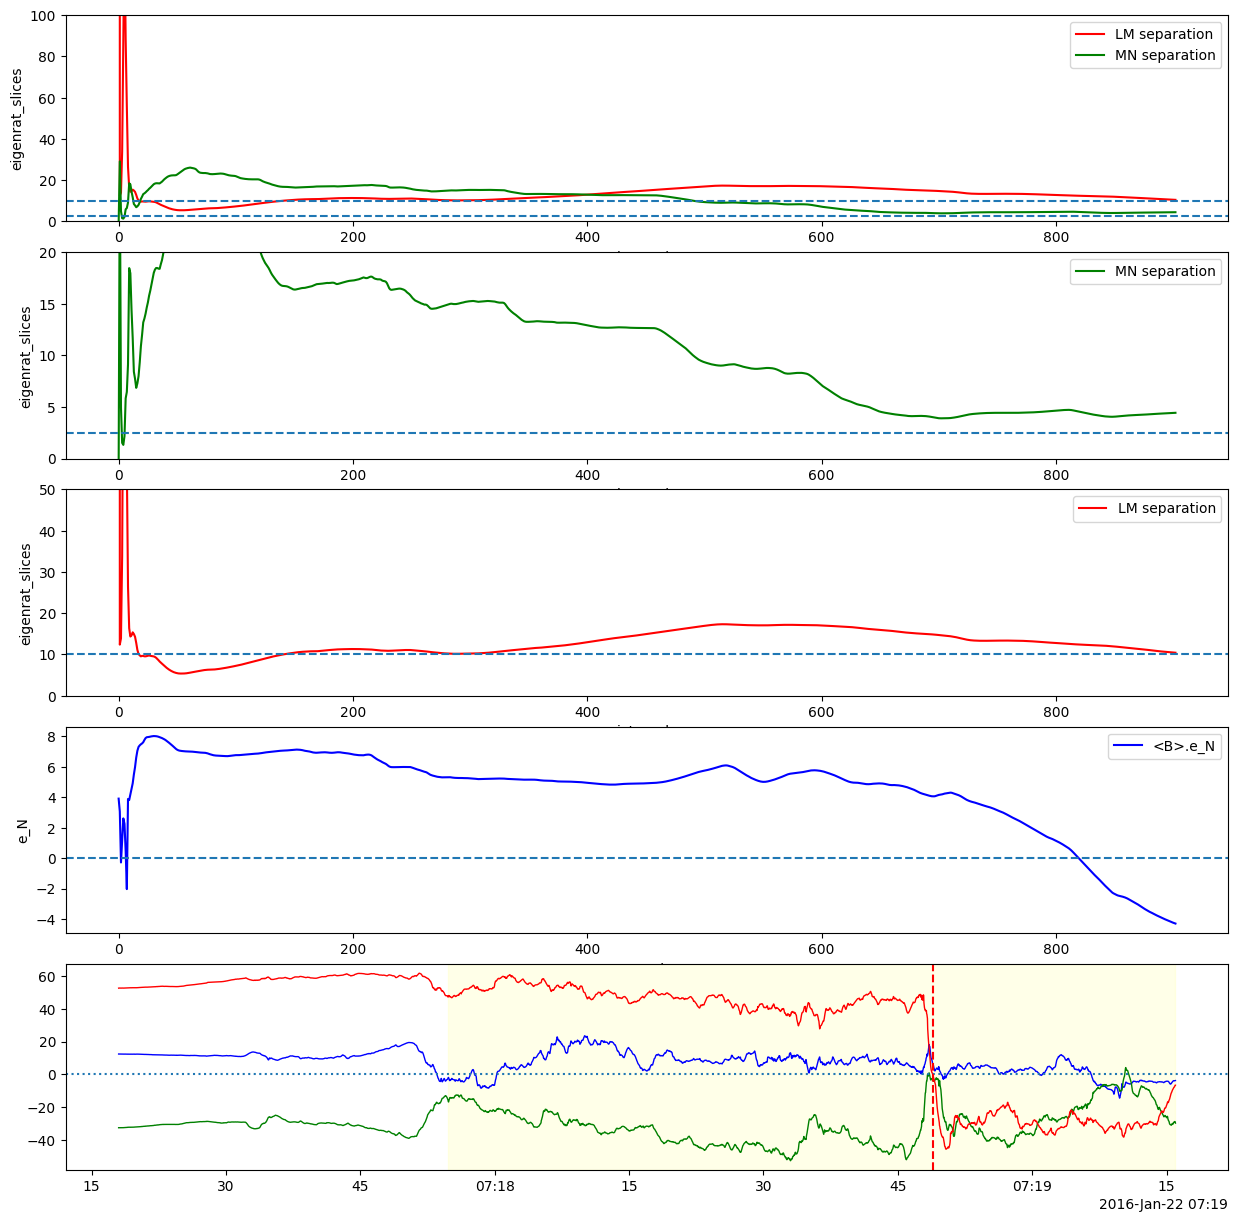

In [19]:
eigenrat_slices = []
eigenval_slices = []
mean_slices = []
eigenvec_slices = []
ndot_slices = []

indices_data = []
time_data = []
index_data= []

additional_points = range(0, zero_crossing[0] +1)  # Adjust range based on crossing_index
start_index = zero_crossing[0]
end_index = zero_crossing[0] + 2

while True:
    if start_index <= 0 or end_index >= len(mms1i_bdataset.mms1_fgm_b_gse_brst_l2.time.sel(time=slice(del3, del4))):
         break
        # Get start and end times
    start_time = mms1i_bdataset.mms1_fgm_b_gse_brst_l2.time.sel(time=slice(del3, del4)).isel(time=start_index).values
    end_time = mms1i_bdataset.mms1_fgm_b_gse_brst_l2.time.sel(time=slice(del3, del4)).isel(time=end_index).values
    mean = mms1i_bdataset.mms1_fgm_b_gse_brst_l2.sel(time=slice(del3, del4),v_dim=slice(0,3)).isel(time=slice(start_index,end_index)).mean(dim='time')
        # Append data
    LMN = mva_b(mms1i_bdataset.mms1_fgm_b_gse_brst_l2.sel(time=slice(del3, del4)).isel(time=slice(start_index, end_index)))[0]
    eigenrat_slices.append(LMN.eigenrat.values)
    eigenval_slices.append(LMN.eigenval.values)
    mean_slices.append(mean)
    eigenvec_slices.append(LMN.eigenvec.sel(LMN=2).values)
    indices_data.append([start_index, end_index])
    index_data.append(start_index)
    time_data.append([start_time, end_time])
        # Update start_index and end_index for the next iteration
    start_index -= 2
    end_index += 1
       
nested_mva = xr.Dataset({
    'eigenrat_slices': (['intervals', 'ratios'], eigenrat_slices),
    'eigenval_slices': (['intervals', 'values'], eigenval_slices),
    'e_N': (['intervals','values'], eigenvec_slices),
    'B_av': (['intervals','values'], mean_slices),
}, coords={
    'indices': (['intervals', 'range'], indices_data),
    'start_index': (['intervals'], index_data),
    'time': (['intervals', 'range'], time_data)
})

fig, ax = plt.subplots(5,1,figsize=(15, 15),sharex=False, gridspec_kw={'hspace': 0.15})
nested_mva.eigenrat_slices.sel(ratios=0).plot(ax=ax[0], color='r', label='LM separation')
nested_mva.eigenrat_slices.sel(ratios=1).plot(ax=ax[0], color='g', label='MN separation')
ax[0].set_ylim(0, 100)
ax[0].axhline(y=2.5,ls='--')
ax[0].axhline(y=10,ls='--')
ax[0].legend()
nested_mva.eigenrat_slices.sel(ratios=1).plot(ax=ax[1], color='g', label='MN separation')
ax[1].set_ylim(0, 20)
ax[1].axhline(y=2.5,ls='--')
ax[1].legend()
nested_mva.eigenrat_slices.sel(ratios=0).plot(ax=ax[2], color='r', label='LM separation')
ax[2].set_ylim(0, 50)
ax[2].axhline(y=10,ls='--')
ax[2].legend()
xr.dot(nested_mva.e_N,nested_mva.B_av,dim=['values']).plot(ax=ax[3], color='b',label='<B>.e_N')
ax[3].set_xlabel('Nest_Size')
ax[3].axhline(y=0,ls='--')
ax[3].legend()

ax[4].plot(mms1i_bdataset.time.sel(time=slice(del3,del4)),mms1i_bdataset.mms1_fgm_b_gse_brst_l2.sel(time=slice(del3,del4),v_dim=0), c='b', lw=1, label='Bx')
ax[4].plot(mms1i_bdataset.time.sel(time=slice(del3,del4)),mms1i_bdataset.mms1_fgm_b_gse_brst_l2.sel(time=slice(del3,del4),v_dim=1), c='g', lw=1, label='By')
ax[4].plot(mms1i_bdataset.time.sel(time=slice(del3,del4)),mms1i_bdataset.mms1_fgm_b_gse_brst_l2.sel(time=slice(del3,del4),v_dim=2), c='r', lw=1, label='Bz')
ax[4].axvspan(nested_mva.time[-1][0].values, nested_mva.time[-1][1].values,color=(1, 1, 0.7), alpha=0.3, label='Highlighted Span')
ax[4].axhline(y=0,ls=':')
ax[4].axvline(Bz.values,ls='--',c='r') #value obtained form below,change to MP crossing timestamp accordingly
plt.savefig(os.path.join(output_folder, f"b{1,1}.png"), dpi=50)
plt.show()

In [46]:
hello = nested_mva.e_N.to_dataframe().reset_index()
csv_path = os.path.join(output_folder, 'e_N.csv')
hello.to_csv(csv_path, index=False)

In [ ]:
nested_mva.hvplot(x='intervals',y='eigenrat_slices',autorange='y',by='ratios')

In [ ]:
nested_mva.isel(intervals=150)

In [20]:
v=mva_b(mms1i_bdataset.mms1_fgm_b_gse_brst_l2.sel(time=slice(nested_mva.isel(intervals=600).time[0],nested_mva.isel(intervals=600).time[1])))[0]
v

<xarray.Dataset> Size: 112B
Dimensions:   (ratios: 2, values: 3, vec: 3, LMN: 3)
Dimensions without coordinates: ratios, values, vec, LMN
Data variables:
    eigenrat  (ratios) float64 16B 17.01 7.099
    eigenval  (values) float64 24B 1.203e+03 70.73 9.963
    eigenvec  (vec, LMN) float64 72B 0.06849 -0.009182 ... -0.1519 -0.06909

# Plasma Calculations

In [21]:
ni = mms1i_idataset.mms1_dis_numberdensity_brst.sel(time=slice(del3,del4))
ne = mms1i_edataset.mms1_des_numberdensity_brst.sel(time=slice(del3,del4))
vi = mms1i_idataset.mms1_dis_bulkv_gse_brst.sel(time=slice(del3,del4),v_dim=slice(0,3))
ve = mms1i_edataset.mms1_des_bulkv_gse_brst.sel(time=slice(del3,del4),v_dim=slice(0,3))

def alfven_speed(B,n_i):
    mu_0 = 4 * np.pi * 1e-7
    m = 1.67e-27
    alfven_speed = 1e-3 * np.abs(1e-9 * B)/np.sqrt(mu_0 * 1e6* n_i * m)
    return alfven_speed
def hall_current(i,e):
    q = 1e-19
    j_fpi = 1e6 * 1e9 * 1e3 * q * (i - e)
    return j_fpi
    

lmn_b = xr.apply_ufunc(np.matmul,
                       mms1i_brdataset.mms1_fgm_b_gse_brst_l2.sel(time=slice(del3,del4),v_dim=slice(0,3)),
                       v.eigenvec,
                       input_core_dims=[['time','v_dim'],['vec','LMN']],
                       output_core_dims=[['time','LMN']],
                       dask='allowed')

V_a = xr.apply_ufunc(alfven_speed,
            lmn_b.sel(LMN=0),
            mms1i_idataset.mms1_dis_numberdensity_brst.sel(time=slice(del3,del4)))
lmn_e = xr.apply_ufunc(np.matmul,
                       mms1i_Edataset.sel(time=slice(del3,del4),v_dim=slice(0,3)),
                       v.eigenvec,
                       input_core_dims=[['time','v_dim'],['vec','LMN']],
                       output_core_dims=[['time','LMN']],
                       dask='allowed')


j_fpi = xr.apply_ufunc(
    hall_current,
    ne*vi, ne*ve,
    input_core_dims=[['v_dim'], [ 'v_dim']],
    output_core_dims=[['v_dim']],
    vectorize=True)  # Set to True if your function can handle array inputs   

lmn_vi = xr.apply_ufunc(np.matmul,
                       mms1i_idataset.mms1_dis_bulkv_gse_brst.sel(time=slice(del3,del4),v_dim=slice(0,3)),
                       v.eigenvec,
                       input_core_dims=[['time','v_dim'],['vec','LMN']],
                       output_core_dims=[['time','LMN']],
                       dask='allowed')

lmn_ve = xr.apply_ufunc(np.dot,
               mms1i_edataset.mms1_des_bulkv_gse_brst.sel(time=slice(del3,del4),v_dim=slice(0,3)),
               v.eigenvec.sel(LMN=0),
                input_core_dims = [['time','v_dim'],['vec']],
               output_core_dims=[['time']],
              vectorize=True)

lmn_j = xr.apply_ufunc(np.matmul,
                       j_fpi,
                       v.eigenvec,
                       input_core_dims=[['time','v_dim'],['vec','LMN']],
                       output_core_dims=[['time','LMN']],
                       dask='allowed')

ln_b = lmn_b.sel(LMN=[0,2])/np.linalg.norm(lmn_b.sel(LMN=[0,2]),axis=1,keepdims=True)
ln_j = xr.dot(ln_b,lmn_j.sel(LMN=[0,2]),dim=['LMN','LMN'])*ln_b
par_ln_j = xr.dot(ln_j,ln_b, dim=['LMN','LMN'])
perln_j = lmn_j.sel(LMN=[0,2]) - ln_j
per_ln_j = xr.apply_ufunc(np.linalg.norm,
                          perln_j,
                          input_core_dims=[['LMN']],
                          output_core_dims=[[]],vectorize=True)

In [22]:
# Assuming 'dataset' is your xarray dataset and 'variable' is the variable within it
variable = lmn_b.sel(LMN=0,time=slice(del3,del4))

# Calculate the sign of the variable
sign_variable = np.sign(variable)

# Find where sign changes occur
sign_change_indices = np.where((sign_variable.shift(time=-1) * sign_variable) < 0)

# Infer timestaacmps corresponding to sign changes
Bl = variable.time[sign_change_indices][0]

Bl.values,sign_change_indices

(numpy.datetime64('2016-01-22T07:18:48.936751000'),
 (array([3031], dtype=int64),))

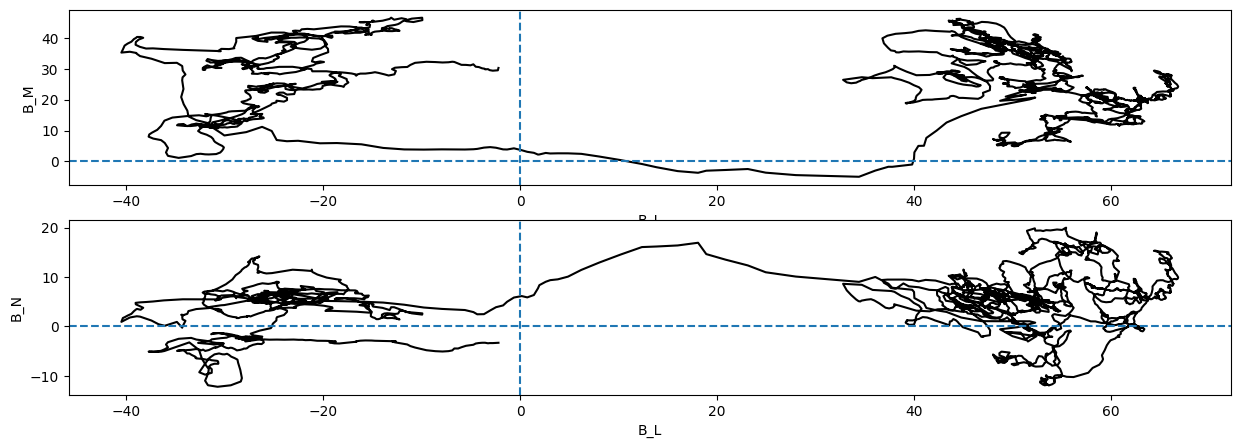

In [23]:
# Create subplots with 1 row and 2 columns
fig, ax = plt.subplots(2, 1, figsize=(15, 5), gridspec_kw={'wspace': 0.5})

# Plot for the first subplot (left column)
ax[0].plot( lmn_b.sel(LMN=0),lmn_b.sel(LMN=1),c='k')
ax[0].set_ylabel('B_M')
ax[0].set_xlabel('B_L')
ax[0].axhline(y=0,ls='--')
ax[0].axvline(x=0,ls='--')
# Plot for the second subplot (right column)
ax[1].plot(lmn_b.sel(LMN=0),lmn_b.sel(LMN=2),c='k')
ax[1].set_xlabel('B_L')  # Correctly set the x-axis label for the second plot
ax[1].set_ylabel('B_N')
ax[1].axhline(y=0,ls='--')
ax[1].axvline(x=0,ls='--')
# Adjust the layout and display the plots
plt.show()

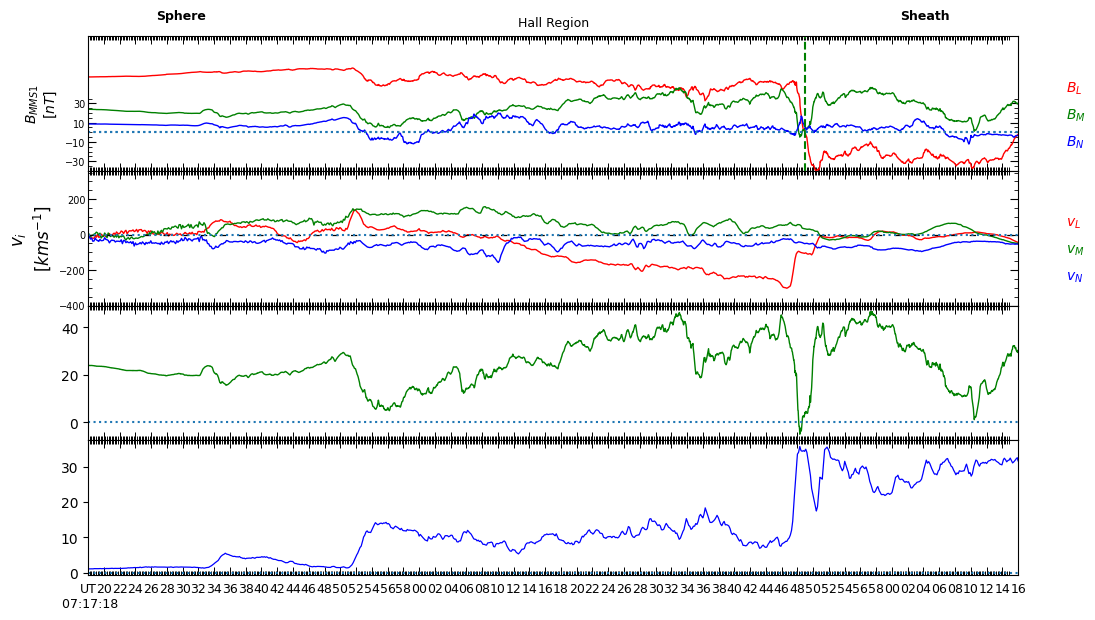

In [24]:
figb,axsb = plt.subplots(4, 1, figsize=[12, 7], sharex=True, gridspec_kw={'hspace': 0})

plasma_region = ['Sheath','Sphere']

if mms1i_bdataset.mms1_fgm_b_gse_brst_l2.sel(v_dim=2,time=slice(del3,del4)).values[0]>0:
    plasma_region = ['Sphere','Sheath']

axsb[0].annotate(f'{plasma_region[0]}', xy=(0.1, 1.1), xycoords='axes fraction',
                 xytext=(0, 5), textcoords='offset points',
                 ha='center', va='center', fontsize=9,fontweight='bold', color='black')
axsb[0].annotate('Hall Region', xy=(0.5, 1.05), xycoords='axes fraction',
                 xytext=(0, 5), textcoords='offset points',
                 ha='center', va='center', fontsize=9, color='black')
axsb[0].annotate(f'{plasma_region[1]}', xy=(0.9, 1.1), xycoords='axes fraction',
                 xytext=(0, 5), textcoords='offset points',
                 ha='center', va='center', fontsize=9, fontweight='bold',color='black')    

axsb[0].plot(lmn_b.time.sel(time=slice(del3,del4)),lmn_b.sel(LMN=0,time=slice(del3,del4)),c='r',lw=1, label='E_L')
axsb[0].plot(lmn_b.time.sel(time=slice(del3,del4)),lmn_b.sel(LMN=1,time=slice(del3,del4)),c='g',lw=1, label='E_M')
axsb[0].plot(lmn_b.time.sel(time=slice(del3,del4)),lmn_b.sel(LMN=2,time=slice(del3,del4)),c='b',lw=1, label='E_N')
axsb[0].axhline(y=0,ls=':')
axsb[0].annotate(r'$\mathit{B_L}$', xy=(1.05, 0.6), xycoords='axes fraction', style='italic',
             fontsize=10, color='red', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red
axsb[0].annotate(r'$\mathit{B_M}$', xy=(1.05, 0.4), xycoords='axes fraction', style='italic',
             fontsize=10, color='green', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axsb[0].annotate(r'$\mathit{B_N}$', xy=(1.05, 0.2), xycoords='axes fraction', style='italic',
             fontsize=10, color='blue', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axsb[0].set_xlim(mms1i_bdataset.time.sel(time=slice(del3,del4))[0], mms1i_bdataset.time.sel(time=slice(del3,del4))[-1])
axsb[0].set_ylabel(r'$\mathbf{\mathit{B_{MMS1}}}$' + '\n' + r'$\mathit{[nT]}$', fontsize=10)
axsb[0].set_yticks(np.arange(np.round(np.min(lmn_e.sel(LMN=0)),-1)-50, np.round(np.max(lmn_e.sel(LMN=0)),-1)+30, 20))
axsb[0].set_yticks(np.arange(np.round(np.min(lmn_e.sel(LMN=0)),-1)-50, np.round(np.max(lmn_e.sel(LMN=0)),-1), 5)+30, minor=True)
axsb[0].tick_params(axis='y', which='major', labelsize=7,size=6,pad=2,direction='in',left=True,right=True)
axsb[0].tick_params(axis='y', which='minor', labelsize=6,size=3,pad=1,direction='in',left=True,right=True)
axsb[0].set_ylim(np.round(np.min(lmn_b[:,0]),-1),np.round(np.max(lmn_b[:,0])+30,-1))
axsb[0].axvline(x=Bl.values,ls='--',c='g')

axsb[1].plot(lmn_vi.time.sel(time=slice(del3,del4)), 
           lmn_vi.sel(LMN=0,time=slice(del3,del4)), c='r', lw=1,label='v_l')
axsb[1].plot(mms1i_idataset.time.sel(time=slice(del3,del4)), 
            lmn_vi.sel(LMN=1,time=slice(del3,del4)), c='g', lw=1,label='v_m')
axsb[1].plot(mms1i_idataset.time.sel(time=slice(del3,del4)), 
            lmn_vi.sel(LMN=2,time=slice(del3,del4)), c='b', lw=1,label='v_n')

axsb[1].axhline(y=0, c='k',  ls=(0, (5, 10)), lw=0.9)
axsb[1].set_ylabel(r'$\mathbf{\mathit{v_{i}}}$' + '\n' + r'$\mathit{[kms^{-1}]}$', fontsize=12)

axsb[1].annotate(r'$\mathit{v_{L}}$', xy=(1.05, 0.6), xycoords='axes fraction', style='italic',
                fontsize=10, color='red', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axsb[1].annotate(r'$\mathit{v_{M}}$', xy=(1.05, 0.4), xycoords='axes fraction', style='italic',
                fontsize=10, color='green', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axsb[1].annotate(r'$\mathit{v_{N}}$', xy=(1.05, 0.2), xycoords='axes fraction', style='italic',
                fontsize=10, color='blue', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red
axsb[1].set_yticks(np.arange(np.round(np.min(lmn_vi), -1)-100, 
                            np.round(np.max(lmn_vi), -1)+400, 200))
axsb[1].set_yticks(np.arange(np.round(np.min(lmn_vi), -1)-100, 
                            np.round(np.max(lmn_vi), -1) + 200, 50), minor=True)
axsb[1].tick_params(axis='y', which='major', labelsize=7,size=6,pad=2,direction='in',left=True,right=True)
axsb[1].tick_params(axis='y', which='minor', labelsize=6,size=3,pad=1,direction='in',left=True,right=True)
axsb[1].set_ylim(np.round(np.min(lmn_vi), -1)-100,np.round(np.max(lmn_vi), -1)+200)

axsb[2].plot(lmn_b.time.sel(time=slice(del3,del4)),lmn_b.sel(LMN=1,time=slice(del3,del4)),c='g',lw=1, label='E_M')
axsb[3].plot(mms1i_idataset.time.sel(time=slice(del3,del4)), 
            mms1i_idataset.mms1_dis_numberdensity_brst.sel(time=slice(del3,del4)), c='b', lw=0.9)
# Custom formatting function
for ax in axsb:
    # Set major x-axis ticks
    ax.set_xticks(major_ticks)

    # Set minor x-axis ticks
    ax.set_xticks(minor_ticks, minor=True)

    # Format x-axis tick labels using the custom function
    formatted_major_ticks = [format_tick_label(t) for t in major_ticks]
    ax.set_xticklabels(formatted_major_ticks, rotation=0, fontsize=12)
    ax.tick_params(axis='x', which='major', labelsize=9,size=6,width=0.7,pad=5,direction='in',top=True,bottom=True)
    ax.tick_params(axis='x', which='minor', labelsize=9,size=3,width=0.7,pad=1,direction='in',top=True,bottom=True)
    ax.axhline(y=0,ls=':')

In [35]:
[del3,del4]

['2016-01-11T06:39:34.013281000', '2016-01-11T06:41:13.943281000']

In [49]:
[del3,del4] = ['2016-01-11T06:39:56.', '2016-01-11T06:40:56']

# Custom formatting function
def format_tick_label(tick_time):
    if tick_time == major_ticks[0]:
        return f"UT\n {np.datetime_as_string(tick_time, unit='s')[11:]}"
    else:
        return np.datetime_as_string(tick_time, unit='s')[17:]
        
# Generate ticks at regular intervals for major ticks
major_interval = np.timedelta64(2, 's')  # Set interval to 1 second, adjust as needed
start_time = np.datetime64(del3)
plot_date = np.datetime_as_string(start_time, unit='D')
end_time = np.datetime64(del4)
major_ticks = np.arange(start_time, end_time + major_interval, major_interval)
# Generate ticks at regular intervals for minorticks
minor_interval = np.timedelta64(200, 'ms')  # Set interval to 100 milliseconds, adjust as needed
minor_ticks = np.arange(start_time, end_time, minor_interval)

In [25]:
df = pd.DataFrame(columns=['BG/B_L-SP', 'B_SP/B_SH','N_SH/N_SP','SHEAR','BG','Bl_sh'])
df.columns = ['$\\frac{B_{G}}{B_{L-SP}}$', '$\\frac{B_{SP}}{B_{SH}}$', '$\\frac{N_{SH}}{N_{SP}}$', 'shear','$B_g$','$B_{lsh}$']

def B_G(t1,t2):
    if lmn_b.sel(LMN=0,time=slice(del3,Bl)).values[0]>0:
        b_sp = lmn_b.sel(time=slice(del3,t1)).mean(dim='time').values
        b_sh = lmn_b.sel(time=slice(t2,del4)).mean(dim='time').values
        BL_SP = lmn_b.sel(LMN=0,time=slice(del3,t1)).mean(dim='time').values
        BL_SH = lmn_b.sel(LMN=0,time=slice(t2,del4)).mean(dim='time').values
        BM_G = lmn_b.sel(LMN=1,time=slice(t2,del4)).mean(dim='time').values 
        N_SH = mms1i_idataset.mms1_dis_numberdensity_brst.sel(time=slice(t2,del4)).mean(dim='time').values + \
        mms1i_edataset.mms1_des_numberdensity_brst.sel(time=slice(t2,del4)).mean(dim='time').values
        N_SP = mms1i_idataset.mms1_dis_numberdensity_brst.sel(time=slice(del3,t1)).mean(dim='time').values + \
        mms1i_edataset.mms1_des_numberdensity_brst.sel(time=slice(del3,t1)).mean(dim='time').values 
        
    else:
        b_sp = lmn_b.sel(time=slice(t2,del4)).mean(dim='time').values
        b_sh = lmn_b.sel(time=slice(del3,t1)).mean(dim='time').values
        BL_SP = lmn_b.sel(LMN=0,time=slice(t2,del4)).mean(dim='time').values
        BL_SH = lmn_b.sel(LMN=0,time=slice(del3,t1)).mean(dim='time').values
        BM_G = lmn_b.sel(LMN=1,time=slice(del3,t1)).mean(dim='time').values 
        N_SP = mms1i_idataset.mms1_dis_numberdensity_brst.sel(time=slice(t2,del4)).mean(dim='time').values + \
        mms1i_edataset.mms1_des_numberdensity_brst.sel(time=slice(t2,del4)).mean(dim='time').values
        N_SH = mms1i_idataset.mms1_dis_numberdensity_brst.sel(time=slice(del3,t1)).mean(dim='time').values + \
        mms1i_edataset.mms1_des_numberdensity_brst.sel(time=slice(del3,t1)).mean(dim='time').values 
        BG = lmn_b.sel(LMN=1,time=slice(del3,t1)).mean(dim='time').values
        
    b0_sh = np.linalg.norm(b_sh)
    b0_sp = np.linalg.norm(b_sp)
    
    cos_theta = np.dot(b_sp,b_sh)/(b0_sh*b0_sp)
    
    theta_shear = np.degrees(np.arccos(cos_theta))

    return [BM_G/BL_SP*100,b0_sp/b0_sh,N_SH/N_SP,theta_shear,BM_G,BL_SH]

df = pd.DataFrame([B_G(np.datetime64(del3)+np.timedelta64(4,'s'),np.datetime64(del4)-np.timedelta64(10,'s'))], columns=df.columns)
Bg = df['$B_g$'].values[0]
df

,$\frac{B_{G}}{B_{L-SP}}$,$\frac{B_{SP}}{B_{SH}}$,$\frac{N_{SH}}{N_{SP}}$,shear,$B_g$,$B_{lsh}$
0,30.074695,1.989841,23.254652,124.803312,17.37022033033594,-26.26366480439815


In [51]:
#np.round(np.min(lmn_b[:,0]),-1)

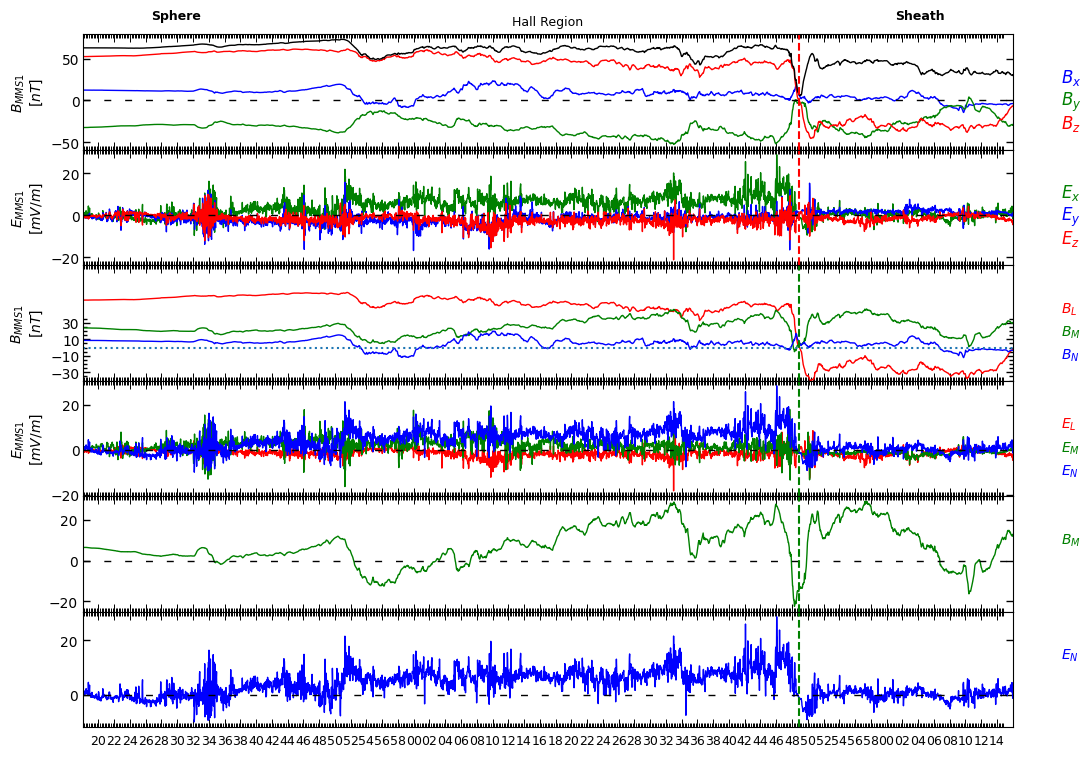

In [26]:
figb,axsb = plt.subplots(6, 1, figsize=[12, 9], sharex=True, gridspec_kw={'hspace': 0})

plasma_region = ['Sheath','Sphere']

if mms1i_bdataset.mms1_fgm_b_gse_brst_l2.sel(v_dim=2,time=slice(del3,del4)).values[0]>0:
    plasma_region = ['Sphere','Sheath']


axsb[0].annotate(f'{plasma_region[0]}', xy=(0.1, 1.1), xycoords='axes fraction',
                 xytext=(0, 5), textcoords='offset points',
                 ha='center', va='center', fontsize=9,fontweight='bold', color='black')
axsb[0].annotate('Hall Region', xy=(0.5, 1.05), xycoords='axes fraction',
                 xytext=(0, 5), textcoords='offset points',
                 ha='center', va='center', fontsize=9, color='black')
axsb[0].annotate(f'{plasma_region[1]}', xy=(0.9, 1.1), xycoords='axes fraction',
                 xytext=(0, 5), textcoords='offset points',
                 ha='center', va='center', fontsize=9, fontweight='bold',color='black')    

axsb[0].plot(mms1i_bdataset.time.sel(time=slice(del3,del4)),mms1i_bdataset.mms1_fgm_b_gse_brst_l2.sel(time=slice(del3,del4),v_dim=0), c='b', lw=1, label='Bx')
axsb[0].plot(mms1i_bdataset.time.sel(time=slice(del3,del4)),mms1i_bdataset.mms1_fgm_b_gse_brst_l2.sel(time=slice(del3,del4),v_dim=1), c='g', lw=1, label='By')
axsb[0].plot(mms1i_bdataset.time.sel(time=slice(del3,del4)),mms1i_bdataset.mms1_fgm_b_gse_brst_l2.sel(time=slice(del3,del4),v_dim=2), c='r', lw=1, label='Bz')
axsb[0].plot(mms1i_bdataset.time.sel(time=slice(del3,del4)),mms1i_bdataset.mms1_fgm_b_gse_brst_l2.sel(time=slice(del3,del4),v_dim=3), c='k', lw=1, label='Bz')
axsb[0].axhline(y=0, c='k', ls=(0, (5, 10)), lw=1)
axsb[0].annotate(r'$\mathit{B_x}$', xy=(1.05, 0.6), xycoords='axes fraction', style='italic',
             fontsize=12, c='b', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axsb[0].annotate(r'$\mathit{B_y}$', xy=(1.05, 0.4), xycoords='axes fraction', style='italic',
             fontsize=12, c='g', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axsb[0].annotate(r'$\mathit{B_z}$', xy=(1.05, 0.2), xycoords='axes fraction', style='italic',
             fontsize=12, c='r', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red

axsb[0].tick_params(axis='y', which='major', labelsize=7,size=6,pad=2,direction='in',left=True,right=True)
axsb[0].tick_params(axis='y', which='minor', labelsize=6,size=3,pad=1,direction='in',left=True,right=True)
#axsb[0].set_yticks(np.arange(np.round(np.min(lmn_b[:,0]),-1)-50, np.round(np.max(lmn_b[:,0]),-1)+30, 20))
#axsb[0].set_yticks(np.arange(np.round(np.min(lmn_b[:,0]),-1)-50, np.round(np.max(lmn_b[:,0]),-1), 5)+30, minor=True)
axsb[0].set_ylabel(r'$\mathbf{\mathit{B_{MMS1}}}$' + '\n' + r'$\mathit{[nT]}$', fontsize=10)
#axsb[0].set_xlim(mms1i_bdataset.time.sel(time=del3), mms1i_bdataset.time.sel(time=del4)) no exact del3,del4 in dataset
axsb[2].set_xlim(mms1i_bdataset.time.sel(time=slice(del3,del4))[0], mms1i_bdataset.time.sel(time=slice(del3,del4))[-1])
axsb[0].axvline(x=Bz.values,ls='--',c='r')

axsb[1].plot(mms1i_Edataset.time.sel(time=slice(del3,del4)),mms1i_Edataset.sel(time=slice(del3,del4),v_dim=0), c='g', lw=1, label='Bx')
axsb[1].plot(mms1i_Edataset.time.sel(time=slice(del3,del4)),mms1i_Edataset.sel(time=slice(del3,del4),v_dim=1), c='b', lw=1, label='Bx')
axsb[1].plot(mms1i_Edataset.time.sel(time=slice(del3,del4)),mms1i_Edataset.sel(time=slice(del3,del4),v_dim=2), c='r', lw=1, label='Bx')
axsb[1].axhline(y=0, c='k', ls=(0, (5, 10)), lw=1)
axsb[1].annotate(r'$\mathit{E_x}$', xy=(1.05, 0.6), xycoords='axes fraction', style='italic',
             fontsize=12, c='g', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axsb[1].annotate(r'$\mathit{E_y}$', xy=(1.05, 0.4), xycoords='axes fraction', style='italic',
             fontsize=12, c='b', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axsb[1].annotate(r'$\mathit{E_z}$', xy=(1.05, 0.2), xycoords='axes fraction', style='italic',
             fontsize=12, c='r', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red
axsb[1].tick_params(axis='y', which='major', labelsize=7,size=6,pad=2,direction='in',left=True,right=True)
axsb[1].tick_params(axis='y', which='minor', labelsize=6,size=3,pad=1,direction='in',left=True,right=True)
#axsb[1].set_yticks(np.arange(np.round(np.min(lmn_b[:,0]),-1)-50, np.round(np.max(lmn_b[:,0]),-1)+30, 20))
#axsb[1].set_yticks(np.arange(np.round(np.min(lmn_b[:,0]),-1)-50, np.round(np.max(lmn_b[:,0]),-1), 5)+30, minor=True)
axsb[1].set_ylabel(r'$\mathbf{\mathit{E_{MMS1}}}$' + '\n' + r'$\mathit{[mV/m]}$', fontsize=10)
#axsb[0].set_xlim(mms1i_bdataset.time.sel(time=del3), mms1i_bdataset.time.sel(time=del4)) no exact del3,del4 in dataset
axsb[2].set_xlim(mms1i_Edataset.time.sel(time=slice(del3,del4))[0], mms1i_Edataset.time.sel(time=slice(del3,del4))[-1])
axsb[1].axvline(x=Bz.values,ls='--',c='r')


# Custom formatting function
for ax in axsb:
    # Set major x-axis ticks
    ax.set_xticks(major_ticks)

    # Set minor x-axis ticks
    ax.set_xticks(minor_ticks, minor=True)

    # Format x-axis tick labels using the custom function
    formatted_major_ticks = [format_tick_label(t) for t in major_ticks]
    ax.set_xticklabels(formatted_major_ticks, rotation=0, fontsize=12)
    ax.tick_params(axis='x', which='major', labelsize=9,size=6,width=0.7,pad=5,direction='in',top=True,bottom=True)
    ax.tick_params(axis='x', which='minor', labelsize=9,size=3,width=0.7,pad=1,direction='in',top=True,bottom=True)

axsb[2].plot(mms1i_brdataset.time.sel(time=slice(del3,del4)),lmn_b.sel(LMN=0,time=slice(del3,del4)),c='r',lw=1, label='E_L')
axsb[2].plot(mms1i_brdataset.time.sel(time=slice(del3,del4)),lmn_b.sel(LMN=1,time=slice(del3,del4)),c='g',lw=1, label='E_M')
axsb[2].plot(mms1i_brdataset.time.sel(time=slice(del3,del4)),lmn_b.sel(LMN=2,time=slice(del3,del4)),c='b',lw=1, label='E_N')
axsb[2].axhline(y=0,ls=':')
axsb[2].annotate(r'$\mathit{B_L}$', xy=(1.05, 0.6), xycoords='axes fraction', style='italic',
             fontsize=10, color='red', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red
axsb[2].annotate(r'$\mathit{B_M}$', xy=(1.05, 0.4), xycoords='axes fraction', style='italic',
             fontsize=10, color='green', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axsb[2].annotate(r'$\mathit{B_N}$', xy=(1.05, 0.2), xycoords='axes fraction', style='italic',
             fontsize=10, color='blue', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axsb[2].set_xlim(mms1i_bdataset.time.sel(time=slice(del3,del4))[0], mms1i_bdataset.time.sel(time=slice(del3,del4))[-1])
axsb[2].set_ylabel(r'$\mathbf{\mathit{B_{MMS1}}}$' + '\n' + r'$\mathit{[nT]}$', fontsize=10)
axsb[2].set_yticks(np.arange(np.round(np.min(lmn_e.isel(LMN=0)),-1)-50, np.round(np.max(lmn_e.isel(LMN=0)),-1)+30, 20))
axsb[2].set_yticks(np.arange(np.round(np.min(lmn_e.isel(LMN=0)),-1)-50, np.round(np.max(lmn_e.isel(LMN=0)),-1), 5)+30, minor=True)
axsb[2].tick_params(axis='y', which='major', labelsize=7,size=6,pad=2,direction='in',left=True,right=True)
axsb[2].tick_params(axis='y', which='minor', labelsize=6,size=3,pad=1,direction='in',left=True,right=True)
axsb[2].set_ylim(np.round(np.min(lmn_b[:,0]),-1),np.round(np.max(lmn_b[:,0])+30,-1))
axsb[2].axvline(x=Bl.values,ls='--',c='g')

axsb[3].plot(mms1i_Edataset.time.sel(time=slice(del3,del4)),lmn_e.sel(LMN=0,time=slice(del3,del4)), c='r', lw=1, label='E_L')
axsb[3].plot(mms1i_Edataset.time.sel(time=slice(del3,del4)),lmn_e.sel(LMN=1,time=slice(del3,del4)), c='g', lw=1, label='E_M')
axsb[3].plot(mms1i_Edataset.time.sel(time=slice(del3,del4)),lmn_e.sel(LMN=2,time=slice(del3,del4)), c='b', lw=1, label='E_N')
axsb[3].axhline(y=0, c='k', ls=(0, (5, 10)), lw=1)
axsb[3].annotate(r'$\mathit{E_L}$', xy=(1.05, 0.6), xycoords='axes fraction', style='italic',
           fontsize=10, color='red', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red
axsb[3].annotate(r'$\mathit{E_M}$', xy=(1.05, 0.4), xycoords='axes fraction', style='italic',
             fontsize=10, color='green', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axsb[3].annotate(r'$\mathit{E_N}$', xy=(1.05, 0.2), xycoords='axes fraction', style='italic',
             fontsize=10, color='blue', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axsb[3].tick_params(axis='y', which='major', labelsize=7,size=6,pad=2,direction='in',left=True,right=True)
axsb[3].tick_params(axis='y', which='minor', labelsize=6,size=3,pad=1,direction='in',left=True,right=True)
#axsb[1].set_yticks(np.arange(np.round(np.min(lmn_b[:,0]),-1)-50, np.round(np.max(lmn_b[:,0]),-1)+30, 20))
#axsb[1].set_yticks(np.arange(np.round(np.min(lmn_b[:,0]),-1)-50, np.round(np.max(lmn_b[:,0]),-1), 5)+30, minor=True)
axsb[3].set_ylabel(r'$\mathbf{\mathit{E_{MMS1}}}$' + '\n' + r'$\mathit{[mV/m]}$', fontsize=10)
#axsb[0].set_xlim(mms1i_bdataset.time.sel(time=del3), mms1i_bdataset.time.sel(time=del4)) no exact del3,del4 in dataset
axsb[2].set_xlim(mms1i_bdataset.time.sel(time=slice(del3,del4))[0], mms1i_bdataset.time.sel(time=slice(del3,del4))[-1])
axsb[3].axvline(x=Bl.values,ls='--',c='g')


axsb[4].plot(mms1i_brdataset.time.sel(time=slice(del3,del4)),lmn_b.sel(LMN=1,time=slice(del3,del4))-Bg,c='g',lw=1, label='E_M')
axsb[4].axhline(y=0, c='k', ls=(0, (5, 10)), lw=1)
axsb[4].axvline(x=Bl.values,ls='--',c='g')
axsb[4].annotate(r'$\mathit{B_M}$', xy=(1.05, 0.6), xycoords='axes fraction', style='italic',
           fontsize=10, color='green', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red

axsb[5].plot(mms1i_Edataset.time.sel(time=slice(del3,del4)),lmn_e.sel(LMN=2,time=slice(del3,del4)), c='b', lw=1, label='E_N')
axsb[5].axhline(y=0, c='k', ls=(0, (5, 10)), lw=1)
axsb[5].axvline(x=Bl.values,ls='--',c='g')
axsb[5].annotate(r'$\mathit{E_N}$', xy=(1.05, 0.6), xycoords='axes fraction', style='italic',
           fontsize=10, color='blue', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red
for ax in axsb:
    ax.tick_params(axis='y', which='major', direction='in',left=True,right=True,
                 width=1, length=5,labelsize=10)  # Adjust width and length as needed
    ax.tick_params(axis='y', which='minor', direction='in',left=True,right=True, 
                   width=1, length=3,labelsize=10)

plt.savefig(os.path.join(output_folder, f"{taistarttime}_c.png"), dpi=100)
plt.show()

In [55]:
Bl.values

numpy.datetime64('2015-12-13T00:28:15.177070000')

In [27]:
# Calculating B_M
B_M = lmn_b.isel(LMN=1) - Bg  # Selecting the data for the specified time slices

# Selecting the time range
hall = B_M.sel(time=slice('2015-12-06T23:40:28','2015-12-06T23:38:34'))

# Find zero crossings
sign_changes = np.sign(hall.values[:-1]) != np.sign(hall.values[1:])
hall_times = hall.time[:-1][sign_changes].values
# Debug: Print zero crossing indices
print("Zero crossing indices:")
print(np.where(sign_changes))

# Debug: Print zero crossing times
print("Zero crossing times:")
print(hall_times)

# Printing the results
if hall_times.size > 0:
    print("B_M crosses zero at the following times within the specified range:")
    for t in hall_times:
        print(t)
else:
    print("No zero crossings found for B_M within the specified time range.")

Zero crossing indices:
(array([], dtype=int64),)
Zero crossing times:
[]
No zero crossings found for B_M within the specified time range.


In [57]:
import pandas as pd

# Selecting the data for the specified time slices
first_selection = B_M.sel(time=slice(del3, Bl))
second_selection = B_M.sel(time=slice(Bl, del4))

# Finding the minimum value and its time in the first selection
min_val_first_sel = first_selection.min().values
min_time_first_sel_index = first_selection.argmin(dim='time').item()
min_time_first_sel_timestamp = first_selection.time[min_time_first_sel_index].values

# Finding the maximum value and its time in the second selection
max_val_second_sel = second_selection.max().values
max_time_second_sel_index = second_selection.argmax(dim='time').item()
max_time_second_sel_timestamp = second_selection.time[max_time_second_sel_index].values

# Creating a dictionary with the results
data = {
    'Selection': ['First', 'Second'],
    'Value': [min_val_first_sel, max_val_second_sel],
    'Time': [min_time_first_sel_timestamp, max_time_second_sel_timestamp]
}

# Creating the DataFrame
df2 = pd.DataFrame(data)

df2

,Selection,Value,Time
0,First,-34.52243457141382,2015-12-13 00:28:10.977070
1,Second,15.008515998195026,2015-12-13 00:28:16.497070


In [31]:
df

,$\frac{B_{G}}{B_{L-SP}}$,$\frac{B_{SP}}{B_{SH}}$,$\frac{N_{SH}}{N_{SP}}$,shear,$B_g$,$B_{lsh}$
0,13.551255,1.94597,41.93303,165.49382,8.831458928064785,-32.31489648987907


17-Jun-24 11:41:51: Substituting symbol \perp from STIXGeneral
17-Jun-24 11:41:51: Substituting symbol \perp from STIXGeneral
17-Jun-24 11:41:53: Substituting symbol \perp from STIXGeneral
17-Jun-24 11:41:53: Substituting symbol \perp from STIXGeneral


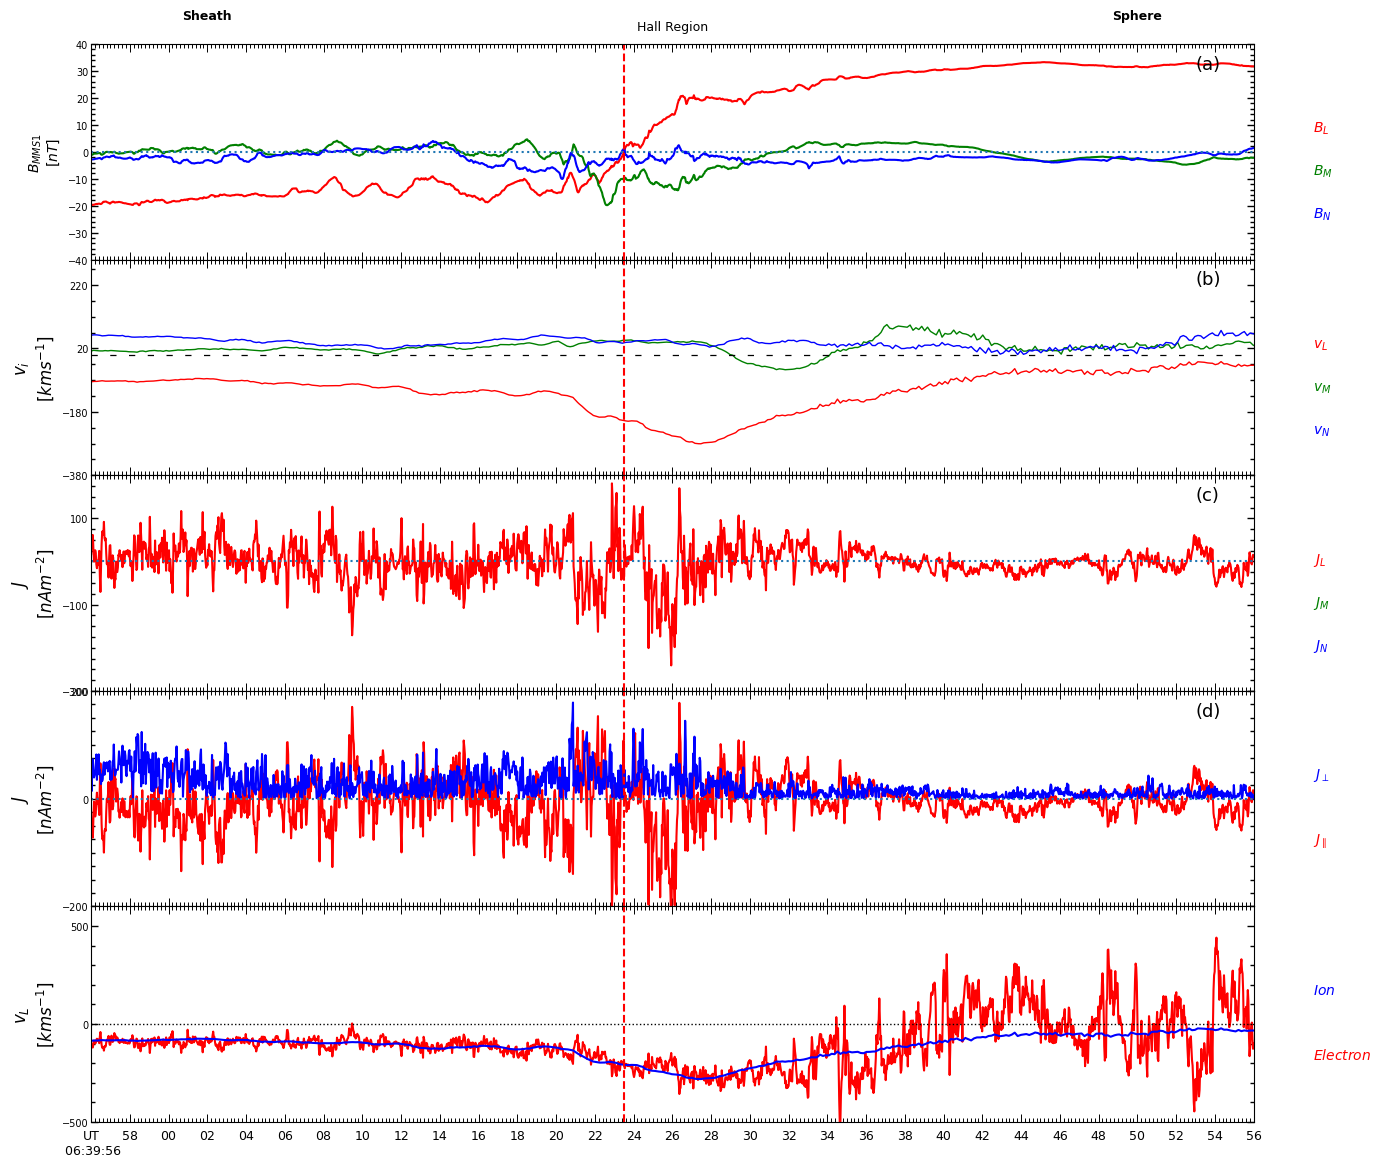

In [53]:
fig, axs = plt.subplots(5, 1, figsize=[15, 14], sharex=True, gridspec_kw={'hspace': 0})
   
axs[0].text(0.95,0.95, '(a)', transform=axs[0].transAxes, fontsize=13, va='top') 
axs[1].text(0.95,0.95, '(b)', transform=axs[1].transAxes, fontsize=13, va='top') 
axs[2].text(0.95,0.95, '(c)', transform=axs[2].transAxes, fontsize=13, va='top') 
axs[3].text(0.95,0.95, '(d)', transform=axs[3].transAxes, fontsize=13, va='top') 


plasma_region = ['Sheath','Sphere']

if lmn_b.sel(LMN=0,time=slice(del3,del4)).values[0]>0:
    plasma_region = ['Sphere','Sheath']

axs[0].annotate(f'{plasma_region[0]}', xy=(0.1, 1.1), xycoords='axes fraction',
                 xytext=(0, 5), textcoords='offset points',
                 ha='center', va='center', fontsize=9,fontweight='bold', color='black')
axs[0].annotate('Hall Region', xy=(0.5, 1.05), xycoords='axes fraction',
                 xytext=(0, 5), textcoords='offset points',
                 ha='center', va='center', fontsize=9, color='black')
axs[0].annotate(f'{plasma_region[1]}', xy=(0.9, 1.1), xycoords='axes fraction',
                 xytext=(0, 5), textcoords='offset points',
                 ha='center', va='center', fontsize=9, fontweight='bold',color='black')  
   


axs[0].plot(lmn_b.time.sel(time=slice(del3,del4)),lmn_b.sel(LMN=0,time=slice(del3,del4)),c='r')
axs[0].plot(lmn_b.time.sel(time=slice(del3,del4)),lmn_b.sel(LMN=1,time=slice(del3,del4))-Bg,c='g')
axs[0].plot(lmn_b.time.sel(time=slice(del3,del4)),lmn_b.sel(LMN=2,time=slice(del3,del4)),c='b')
axs[0].axhline(y=0,ls=':')
axs[0].annotate(r'$\mathit{B_L}$', xy=(1.05, 0.6), xycoords='axes fraction', style='italic',
             fontsize=10, color='red', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red
axs[0].annotate(r'$\mathit{B_M}$', xy=(1.05, 0.4), xycoords='axes fraction', style='italic',
             fontsize=10, color='green', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axs[0].annotate(r'$\mathit{B_N}$', xy=(1.05, 0.2), xycoords='axes fraction', style='italic',
             fontsize=10, color='blue', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axs[0].set_xlim(mms1i_bdataset.time.sel(time=slice(del3,del4))[0], mms1i_bdataset.time.sel(time=slice(del3,del4))[-1])
axs[0].set_ylabel(r'$\mathbf{\mathit{B_{MMS1}}}$' + '\n' + r'$\mathit{[nT]}$', fontsize=10)
axs[0].set_yticks(np.arange(np.round(np.min(lmn_b[:,0]),-1)-10, np.round(np.max(lmn_b[:,0]),-1)+20, 10))
axs[0].set_yticks(np.arange(np.round(np.min(lmn_b[:,0]),-1)-10, np.round(np.max(lmn_b[:,0]),-1)+20, 2), minor=True)
axs[0].tick_params(axis='y', which='major', labelsize=7,size=6,pad=2,direction='in',left=True,right=True)
axs[0].tick_params(axis='y', which='minor', labelsize=6,size=3,pad=1,direction='in',left=True,right=True)
axs[0].set_ylim(np.round(np.min(lmn_b[:,0]),-1)-10,np.round(np.max(lmn_b[:,0]),-1)+10)


axs[1].plot(lmn_vi.time.sel(time=slice(del3,del4)), 
           lmn_vi.sel(LMN=0,time=slice(del3,del4)), c='r', lw=1,label='v_l')
axs[1].plot(lmn_vi.time.sel(time=slice(del3,del4)), 
            lmn_vi.sel(LMN=1,time=slice(del3,del4)), c='g', lw=1,label='v_m')
axs[1].plot(mms1i_idataset.time.sel(time=slice(del3,del4)), 
            lmn_vi.sel(LMN=2,time=slice(del3,del4)), c='b', lw=1,label='v_n')
axs[1].set_xlim(lmn_vi.time.sel(time=slice(del3,del4))[0],
                lmn_vi.time.sel(time=slice(del3,del4))[-1])
axs[1].axhline(y=0, c='k',  ls=(0, (5, 10)), lw=0.9)
axs[1].set_ylabel(r'$\mathbf{\mathit{v_{i}}}$' + '\n' + r'$\mathit{[kms^{-1}]}$', fontsize=12)

axs[1].annotate(r'$\mathit{v_{L}}$', xy=(1.05, 0.6), xycoords='axes fraction', style='italic',
                fontsize=10, color='red', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axs[1].annotate(r'$\mathit{v_{M}}$', xy=(1.05, 0.4), xycoords='axes fraction', style='italic',
                fontsize=10, color='green', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axs[1].annotate(r'$\mathit{v_{N}}$', xy=(1.05, 0.2), xycoords='axes fraction', style='italic',
                fontsize=10, color='blue', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red
axs[1].set_yticks(np.arange(np.round(np.min(lmn_vi), -1)-100, 
                            np.round(np.max(lmn_vi), -1)+400, 200))
axs[1].set_yticks(np.arange(np.round(np.min(lmn_vi), -1)-100, 
                            np.round(np.max(lmn_vi), -1) + 200, 50), minor=True)
axs[1].tick_params(axis='y', which='major', labelsize=7,size=6,pad=2,direction='in',left=True,right=True)
axs[1].tick_params(axis='y', which='minor', labelsize=6,size=3,pad=1,direction='in',left=True,right=True)
axs[1].set_ylim(np.round(np.min(lmn_vi), -1)-100,np.round(np.max(lmn_vi), -1)+200)


axs[2].plot(lmn_j.time.sel(time=slice(del3,del4)),lmn_j.sel(LMN=0,time=slice(del3,del4)),c='r')
# axs[1].plot(lmn_j.time,lmn_j.sel(LMN=1,time=slice(del3,del4)),c='g')
# axs[1].plot(lmn_j.time,lmn_j.sel(LMN=2,time=slice(del3,del4)),c='b')
axs[2].set_xlim(lmn_j.time.sel(time=slice(del3,del4))[0],lmn_j.time.sel(time=slice(del3,del4))[-1])
axs[2].axhline(y=0,ls=':')
axs[2].set_yticks(np.arange(np.round(np.min(lmn_j), -2), np.round(np.max(lmn_j), -2) + 200, 200))
axs[2].set_yticks(np.arange(np.round(np.min(lmn_j), -2), np.round(np.max(lmn_j), -2) + 25, 25), minor=True)
axs[2].tick_params(axis='y', which='major', labelsize=7,size=6,pad=2,direction='in',left=True,right=True)
axs[2].tick_params(axis='y', which='minor', labelsize=7,size=3,pad=1,direction='in',left=True,right=True)

axs[2].annotate(r'$\mathit{J_{L}}$', xy=(1.05, 0.6), xycoords='axes fraction', style='italic',
                fontsize=10, color='red', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axs[2].annotate(r'$\mathit{J_{M}}$', xy=(1.05, 0.4), xycoords='axes fraction', style='italic',
                fontsize=10, color='green', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axs[2].annotate(r'$\mathit{J_{N}}$', xy=(1.05, 0.2), xycoords='axes fraction', style='italic',
                fontsize=10, color='blue', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red
axs[2].set_ylabel(r'$\mathbf{\mathit{J}}$' + '\n' + r'$\mathit{[nA m^{-2}]}$', fontsize=12)
axs[2].set_ylim(np.round(np.min(lmn_j), -2),np.round(np.max(lmn_j), -2))

axs[3].plot(par_ln_j.time.sel(time=slice(del3,del4)),par_ln_j.sel(time=slice(del3,del4)),c='r')
axs[3].plot(par_ln_j.time.sel(time=slice(del3,del4)),per_ln_j.sel(time=slice(del3,del4)),c='b')
axs[3].set_xlim(par_ln_j.time.sel(time=slice(del3,del4))[0],par_ln_j.time.sel(time=slice(del3,del4))[-1])
axs[3].axhline(y=0,ls=':')
axs[3].set_yticks(np.arange(np.round(np.min(par_ln_j), -2), np.round(np.max(par_ln_j), -2) + 200, 200))
axs[3].set_yticks(np.arange(np.round(np.min(par_ln_j), -2), np.round(np.max(par_ln_j), -2) + 25, 25), minor=True)
axs[3].tick_params(axis='y', which='major', labelsize=7,size=6,pad=2,direction='in',left=True,right=True)
axs[3].tick_params(axis='y', which='minor', labelsize=7,size=3,pad=1,direction='in',left=True,right=True)

axs[3].annotate(r'$J_{\perp}$', xy=(1.05, 0.6), xycoords='axes fraction', style='italic',
                fontsize=10, color='blue', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axs[3].annotate(r'$J_{\parallel}$', xy=(1.05, 0.3), xycoords='axes fraction', style='italic',
                fontsize=10, color='red', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axs[3].set_ylabel(r'$\mathbf{\mathit{J}}$' + '\n' + r'$\mathit{[nA m^{-2}]}$', fontsize=12)
axs[3].set_ylim(np.round(np.min(par_ln_j), -2),np.round(np.max(par_ln_j), -2))


axs[4].plot(lmn_ve.time.sel(time=slice(del3,del4)),lmn_ve.sel(time=slice(del3,del4)),c='r')
axs[4].plot(lmn_ve.time.sel(time=slice(del3,del4)),lmn_vi.sel(LMN=0,time=slice(del3,del4)),c='b')
axs[4].axhline(y=0,ls=':',lw=1,c='k')
axs[4].set_yticks(np.arange(np.round(np.min(lmn_ve,), -2), np.round(np.max(lmn_ve,), -2) + 500, 500))
axs[4].set_yticks(np.arange(np.round(np.min(lmn_ve,), -2), np.round(np.max(lmn_ve,), -2) + 100, 100), minor=True)
axs[4].tick_params(axis='y', which='major', labelsize=7,size=6,pad=2,direction='in',left=True,right=True)
axs[4].tick_params(axis='y', which='minor', labelsize=6,size=3,pad=1,direction='in',left=True,right=True)
axs[4].set_xlim(np.datetime64(del3), np.datetime64(del4))
axs[4].annotate(r'$Ion$', xy=(1.05, 0.6), xycoords='axes fraction', style='italic',
               fontsize=10, color='blue', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axs[4].annotate(r'$Electron$', xy=(1.05, 0.3), xycoords='axes fraction', style='italic',
                fontsize=10, color='red', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axs[4].set_ylabel(r'$\mathbf{\mathit{v_L}}$' + '\n' + r'$\mathit{[km s^{-1}]}$', fontsize=12)
axs[4].set_ylim(np.round(np.min(lmn_ve), -2),np.round(np.max(lmn_ve), -2))


for ax in axs:
    # Set major x-axis ticks
    ax.set_xticks(major_ticks)

    # Set minor x-axis ticks
    ax.set_xticks(minor_ticks, minor=True)

    # Format x-axis tick labels using the custom function
    formatted_major_ticks = [format_tick_label(t) for t in major_ticks]
    ax.set_xticklabels(formatted_major_ticks, rotation=0, fontsize=10)
    ax.tick_params(axis='x', which='major', labelsize=9,size=6,width=0.7,pad=5,direction='in',top=True,bottom=True)
    ax.tick_params(axis='x', which='minor', labelsize=9,size=3,width=0.7,pad=1,direction='in',top=True,bottom=True)
    # ax.axvspan(hall_times[1],hall_times[2],
    # color=(1, 1, 0.7), alpha=0.3, label='Highlighted Span')
    # ax.axvspan(hall_times[2],hall_times[5],
    #            color=(1, 1, 0.2), alpha=0.3, label='Highlighted Span')

# Draw rectangles with arrows and boxes
#axis_coords1 = axs[0].transAxes.inverted().transform((axs[0].transData.transform((mdates.datestr2num('2015-12-06T23:29:00.000'), 0))))[0]
#axis_coords2 = axs[0].transAxes.inverted().transform((axs[0].transData.transform((mdates.datestr2num('2015-12-06T23:29:02.300'), 0))))[0]
#axis_coords3 = axs[0].transAxes.inverted().transform((axs[0].transData.transform((mdates.datestr2num('2015-12-06T23:29:15.400'), 0))))[0]
#axis_coords4 = axs[0].transAxes.inverted().transform((axs[0].transData.transform((mdates.datestr2num('2015-12-06T23:29:18.000'), 0))))[0]

# axs[0].annotate('', xy=(axis_coords1, 1.05), xytext=(axis_coords2, 1.05), xycoords='axes fraction', textcoords='axes fraction',
#                  arrowprops=dict(facecolor='black', edgecolor='black', arrowstyle='wedge', lw=1.5))
#axs[0].annotate('', xy=(axis_coords4, 1.05), xytext=(axis_coords3, 1.05), xycoords='axes fraction', textcoords='axes fraction',
#                 arrowprops=dict(facecolor='black', edgecolor='black', arrowstyle='wedge', lw=1.5))
    #ax.axvspan(mdates.datestr2num('2015-12-06T23:29:05.000'), mdates.datestr2num('2015-12-06T23:29:08.600'), 
    #           color=(1, 1, 0.7), alpha=0.3, label='Highlighted Span')
    #ax.axvspan(mdates.datestr2num('2015-12-06T23:29:08.600'), mdates.datestr2num('2015-12-06T23:29:12.000'),
     #          color=(1, 1, 0.2), alpha=0.3, label='Highlighted Span')
for ax in axs:
    ax.tick_params(axis='y', which='major', direction='in',left=True,right=True,
                 width=1, length=5,labelsize=7)  # Adjust width and length as needed
    ax.tick_params(axis='y', which='minor', direction='in',left=True,right=True, 
                   width=1, length=3,labelsize=7)
    ax.axvline(x=Bl.values,ls='--',c='r')
plt.rc('mathtext', fontset='stix')
plt.rc('font', family='STIXGeneral')
plt.savefig(os.path.join(output_folder, f"{taistarttime}_c.png"), dpi=100)
plt.show()

In [45]:
# Calculate sheath average speed
sheath_avg_speed = lmn_vi.sel(LMN=0, time=slice(del3, Bl)).mean().values

# Calculate sheath Alfven speed
sheath_alfven_speed = V_a.sel(time=slice(del3, Bl)).max().values

# Calculate velocity jet max and its corresponding time
V_L = lmn_vi.sel(LMN=0, time=slice(Bl, del4))
min_val_first_sel = V_L.min().values
min_time_first_sel_index = V_L.argmin(dim='time').item()
min_time_first_sel_timestamp = V_L.time[min_time_first_sel_index].values

# Create a dictionary with the results
data = {
    'Plasma Parameter': ['Sheath average speed', 'Sheath Alfven speed', 'V_L jet max', 'V_L Jet time'],
    'Value': [sheath_avg_speed, sheath_alfven_speed, min_val_first_sel, min_time_first_sel_timestamp]
}

# Create the DataFrame
df2 = pd.DataFrame(data)
df2

,Plasma Parameter,Value
0,Sheath average speed,-256.1638793646972
1,Sheath Alfven speed,1688.0228662923462
2,V_L jet max,-347.50238367005545
3,V_L Jet time,2015-12-17T10:12:45.479576000


In [46]:
# Define a helper function to find max and min times and values within a specified range
def find_extremes(data_array, time_range):
    selected_data = data_array.sel(time=time_range)
    max_index = selected_data.argmax(dim='time').item()
    min_index = selected_data.argmin(dim='time').item()
    max_time = selected_data.time[max_index].values
    min_time = selected_data.time[min_index].values
    max_value = selected_data[max_index].values
    min_value = selected_data[min_index].values
    return max_time, min_time, max_value, min_value

# Calculate times and values for max and min within the specified ranges using the helper function
V_LE_t_max_sp, V_LE_t_min_sp, V_LE_max_sp, V_LE_min_sp = find_extremes(lmn_ve, slice(hall_times[2], hall_times[5]))
V_LE_t_max_sh, V_LE_t_min_sh, V_LE_max_sh, V_LE_min_sh = find_extremes(lmn_ve, slice(hall_times[1], hall_times[2]))

# Calculate the corresponding V_LI values
V_LI_sp1 = lmn_vi.sel(time=V_LE_t_max_sp, LMN=0).values
V_LI_sp2 = lmn_vi.sel(time=V_LE_t_min_sp, LMN=0).values
V_LI_sh1 = lmn_vi.sel(time=V_LE_t_max_sh, LMN=0).values
V_LI_sh2 = lmn_vi.sel(time=V_LE_t_min_sh, LMN=0).values

# Create a dictionary with the computed values
data = {
    'Time': [V_LE_t_max_sp, V_LE_t_min_sp, V_LE_t_max_sh, V_LE_t_min_sh],
    'V_LE': [V_LE_max_sp, V_LE_min_sp, V_LE_max_sh, V_LE_min_sh],
    'V_LI': [V_LI_sp1, V_LI_sp2, V_LI_sh1, V_LI_sh2],
    'i-e Velocity Separation': [
        V_LE_max_sp - V_LI_sp1,
        V_LE_min_sp - V_LI_sp2,
        V_LE_max_sh - V_LI_sh1,
        V_LE_min_sh - V_LI_sh2
    ],
    'Direction': ['+L', '-L', '+L', '-L'],
    'Type': ['sp', 'sp', 'sh', 'sh']
}

# Create the DataFrame
df3 = pd.DataFrame(data)

df3

NameError: name 'hall_times' is not defined

In [ ]:
fig, axs = plt.subplots(8, 1, figsize=[15, 12], sharex=True, gridspec_kw={'hspace': 0})
   
axs[0].text(0.95,0.95, '(a)', transform=axs[0].transAxes, fontsize=13, va='top') 
axs[1].text(0.95,0.95, '(b)', transform=axs[1].transAxes, fontsize=13, va='top') 
axs[2].text(0.95,0.95, '(c)', transform=axs[2].transAxes, fontsize=13, va='top') 
axs[3].text(0.95,0.95, '(d)', transform=axs[3].transAxes, fontsize=13, va='top') 
axs[4].text(0.95,0.95, '(e)', transform=axs[4].transAxes, fontsize=13, va='top') 
axs[5].text(0.95,0.95, '(f)', transform=axs[5].transAxes, fontsize=13, va='top') 
axs[6].text(0.95,0.95, '(g)', transform=axs[6].transAxes, fontsize=13, va='top') 
axs[7].text(0.95,0.95, '(h)', transform=axs[7].transAxes, fontsize=13, va='top') 

plasma_region = ['Sheath','Sphere']

if lmn_b.sel(LMN=0,time=slice(del3,del4)).values[0]>0:
    plasma_region = ['Sphere','Sheath']

axs[0].annotate(f'{plasma_region[0]}', xy=(0.1, 1.1), xycoords='axes fraction',
                 xytext=(0, 5), textcoords='offset points',
                 ha='center', va='center', fontsize=9,fontweight='bold', color='black')
axs[0].annotate('Hall Region', xy=(0.5, 1.05), xycoords='axes fraction',
                 xytext=(0, 5), textcoords='offset points',
                 ha='center', va='center', fontsize=9, color='black')
axs[0].annotate(f'{plasma_region[1]}', xy=(0.9, 1.1), xycoords='axes fraction',
                 xytext=(0, 5), textcoords='offset points',
                 ha='center', va='center', fontsize=9, fontweight='bold',color='black')  


axs[0].plot(lmn_b.time.sel(time=slice(del3,del4)),lmn_b.sel(LMN=0,time=slice(del3,del4)),c='r')
axs[0].plot(lmn_b.time.sel(time=slice(del3,del4)),lmn_b.sel(LMN=1,time=slice(del3,del4))-Bg,c='g')
axs[0].plot(lmn_b.time.sel(time=slice(del3,del4)),lmn_b.sel(LMN=2,time=slice(del3,del4)),c='b')
axs[0].axhline(y=0,ls=':')
axs[0].annotate(r'$\mathit{B_L}$', xy=(1.05, 0.6), xycoords='axes fraction', style='italic',
             fontsize=10, color='red', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red
axs[0].annotate(r'$\mathit{B_M}$', xy=(1.05, 0.4), xycoords='axes fraction', style='italic',
             fontsize=10, color='green', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axs[0].annotate(r'$\mathit{B_N}$', xy=(1.05, 0.2), xycoords='axes fraction', style='italic',
             fontsize=10, color='blue', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axs[0].set_xlim(mms1i_bdataset.time.sel(time=slice(del3,del4))[0], mms1i_bdataset.time.sel(time=slice(del3,del4))[-1])
axs[0].set_ylabel(r'$\mathbf{\mathit{B_{MMS1}}}$' + '\n' + r'$\mathit{[nT]}$', fontsize=10)
axs[0].set_yticks(np.arange(np.round(np.min(lmn_b[:,0]),-1)-10, np.round(np.max(lmn_b[:,0]),-1)+20, 10))
axs[0].set_yticks(np.arange(np.round(np.min(lmn_b[:,0]),-1)-10, np.round(np.max(lmn_b[:,0]),-1)+20, 2), minor=True)
axs[0].tick_params(axis='y', which='major', labelsize=7,size=6,pad=2,direction='in',left=True,right=True)
axs[0].tick_params(axis='y', which='minor', labelsize=6,size=3,pad=1,direction='in',left=True,right=True)
axs[0].set_ylim(np.round(np.min(lmn_b[:,0]),-1)-10,np.round(np.max(lmn_b[:,0]),-1)+10)



axs[1].plot(mms1i_idataset.time.sel(time=slice(del3,del4)), 
            mms1i_idataset.mms1_dis_numberdensity_brst.sel(time=slice(del3,del4)), c='b', lw=0.9)
axs[1].plot(mms1i_edataset.time.sel(time=slice(del3,del4)), 
            mms1i_edataset.mms1_des_numberdensity_brst.sel(time=slice(del3,del4)), c='r', lw=0.9)
axs[1].set_ylabel(r'$\mathbf{\mathit{n_{MMS1}}}$' + '\n' + r'$\mathit{[cm^{-3}]}$', fontsize=10)
axs[1].set_xlim(mms1i_idataset.time.sel(time=slice(del3,del4))[0],
                mms1i_idataset.time.sel(time=slice(del3,del4))[-1])
axs[1].annotate(r'$\mathit{n_i}$', xy=(1.05, 0.6), xycoords='axes fraction', style='italic',
                fontsize=10, color='blue', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axs[1].annotate(r'$\mathit{n_e}$', xy=(1.05, 0.3), xycoords='axes fraction', style='italic',
                fontsize=10, color='red', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axs[1].set_yticks(np.arange(np.round(np.min(mms1i_idataset.mms1_dis_numberdensity_brst.sel(time=slice(del3,del4))), 0), 
                            np.round(np.max(mms1i_idataset.mms1_dis_numberdensity_brst.sel(time=slice(del3,del4))), 0), 1))
axs[1].set_yticks(np.arange(np.round(np.min(mms1i_idataset.mms1_dis_numberdensity_brst.sel(time=slice(del3,del4))), 0), 
                            np.round(np.max(mms1i_idataset.mms1_dis_numberdensity_brst.sel(time=slice(del3,del4))),0), 0.2), minor=True)
axs[1].tick_params(axis='y', which='major', labelsize=7,size=6,pad=2,direction='in',left=True,right=True)
axs[1].tick_params(axis='y', which='minor', labelsize=6,size=3,pad=1,direction='in',left=True,right=True)
axs[1].set_ylim()

# Plot using pcolormesh with LogNorm
specgram = axs[2].pcolormesh(mms1i_edataset.mms1_des_energyspectr_omni_brst.time.sel(time=slice(del3,del4)),
                         mms1i_edataset.mms1_des_energyspectr_omni_brst.spec_bins.sel(time=slice(del3,del4)).mean(dim='time'),
                         mms1i_edataset.mms1_des_energyspectr_omni_brst.sel(time=slice(del3,del4)).T, cmap='jet',
                         norm=mcolors.LogNorm(vmin=1e4, vmax=1e8 * 10 ** 0.8), rasterized=True, shading="auto")
axs[2].set_ylabel("$E_{e}$ [keV]")
axs[2].set_yscale('log')

# Create a new axis for the colorbar
cbar_ax = axs[2].figure.add_axes([0.91, 0.59, 0.004, 0.09])  # Position for the colorbar

# Add colorbar
cbar = plt.colorbar(specgram, cax=cbar_ax)
cbar.set_label("Flux" + "\n" + "[(cm$^2$ s sr keV)$^{-1}$]", fontsize=6)

# Set ticks for colorbar
ticks = np.arange(4, 9)
cbar.set_ticks(10 ** ticks)
cbar.ax.set_yticklabels([f'$10^{{{tick}}}$' for tick in ticks], fontsize=6)


# Plot data on the subplots
axs[3].plot(mms1i_idataset.time.sel(time=slice(del3,del4)), 
          lmn_vi.sel(LMN=0,time=slice(del3,del4)), c='r', lw=1,label='v_l')
axs[3].plot(mms1i_idataset.time.sel(time=slice(del3,del4)), 
            lmn_vi.sel(LMN=1,time=slice(del3,del4)), c='g', lw=1,label='v_m')
axs[3].plot(mms1i_idataset.time.sel(time=slice(del3,del4)), 
            lmn_vi.sel(LMN=2,time=slice(del3,del4)), c='b', lw=1,label='v_n')
axs[3].set_xlim(mms1i_idataset.time.sel(time=slice(del3,del4))[0],
                mms1i_idataset.time.sel(time=slice(del3,del4))[-1])
axs[3].axhline(y=0, c='k',  ls=(0, (5, 10)), lw=0.9)
axs[3].set_ylabel(r'$\mathbf{\mathit{v_{i}}}$' + '\n' + r'$\mathit{[kms^{-1}]}$', fontsize=12)

axs[3].annotate(r'$\mathit{v_{L}}$', xy=(1.05, 0.6), xycoords='axes fraction', style='italic',
                fontsize=10, color='red', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axs[3].annotate(r'$\mathit{v_{M}}$', xy=(1.05, 0.4), xycoords='axes fraction', style='italic',
                fontsize=10, color='green', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axs[3].annotate(r'$\mathit{v_{N}}$', xy=(1.05, 0.2), xycoords='axes fraction', style='italic',
                fontsize=10, color='blue', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red
axs[3].set_yticks(np.arange(np.round(np.min(lmn_vi), -1)-100, 
                            np.round(np.max(lmn_vi), -1)+400, 200))
axs[3].set_yticks(np.arange(np.round(np.min(lmn_vi), -1)-100, 
                            np.round(np.max(lmn_vi), -1) + 200, 50), minor=True)
axs[3].tick_params(axis='y', which='major', labelsize=7,size=6,pad=2,direction='in',left=True,right=True)
axs[3].tick_params(axis='y', which='minor', labelsize=6,size=3,pad=1,direction='in',left=True,right=True)
axs[3].set_ylim(np.round(np.min(lmn_vi), -1)-100,np.round(np.max(lmn_vi), -1)+200)

axs[4].plot(V_a.time.sel(time=slice(del3,del4)),V_a.sel(time=slice(del3,del4)),c='k')
axs[4].set_xlim(V_a.time.sel(time=slice(del3,del4))[0],V_a.time.sel(time=slice(del3,del4))[-1])
axs[4].set_yticks(np.arange(np.round(np.min(V_a), -2), np.round(np.max(V_a), -2)+100, 100))
axs[4].set_yticks(np.arange(np.round(np.min(V_a), -2), np.round(np.max(V_a), -2) + 100, 25), minor=True)
axs[4].tick_params(axis='y', which='major', labelsize=7,size=6,pad=2,direction='in',left=True,right=True)
axs[4].tick_params(axis='y', which='minor', labelsize=7,size=3,pad=1,direction='in',left=True,right=True)
axs[4].set_ylim(np.round(np.min(V_a), -2),np.round(np.max(V_a), -2)+100)
axs[4].set_ylabel(r'$\mathbf{\mathit{v_{A}}}$' + '\n' + r'$\mathit{[kms^{-1}]}$', fontsize=12)

axs[5].plot(lmn_j.time.sel(time=slice(del3,del4)),lmn_j.sel(LMN=0,time=slice(del3,del4)),c='r')
axs[5].plot(lmn_j.time.sel(time=slice(del3,del4)),lmn_j.sel(LMN=1,time=slice(del3,del4)),c='g')
axs[5].plot(lmn_j.time.sel(time=slice(del3,del4)),lmn_j.sel(LMN=2,time=slice(del3,del4)),c='b')
axs[5].set_xlim(V_a.time.sel(time=slice(del3,del4))[0],V_a.sel(time=slice(del3,del4)).time[-1])
axs[5].axhline(y=0,ls=':')
axs[5].set_yticks(np.arange(np.round(np.min(lmn_j), -2), np.round(np.max(lmn_j), -2) + 200, 100))
axs[5].set_yticks(np.arange(np.round(np.min(lmn_j), -2), np.round(np.max(lmn_j), -2) + 200, 20), minor=True)
axs[5].tick_params(axis='y', which='major', labelsize=7,size=6,pad=2,direction='in',left=True,right=True)
axs[5].tick_params(axis='y', which='minor', labelsize=7,size=3,pad=1,direction='in',left=True,right=True)

axs[5].annotate(r'$\mathit{J_{L}}$', xy=(1.05, 0.6), xycoords='axes fraction', style='italic',
                fontsize=10, color='red', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axs[5].annotate(r'$\mathit{J_{M}}$', xy=(1.05, 0.4), xycoords='axes fraction', style='italic',
                fontsize=10, color='green', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axs[5].annotate(r'$\mathit{J_{N}}$', xy=(1.05, 0.2), xycoords='axes fraction', style='italic',
                fontsize=10, color='blue', xytext=(1, -1), textcoords='offset points')  # Annotation for Bz in red
axs[5].set_ylabel(r'$\mathbf{\mathit{J}}$' + '\n' + r'$\mathit{[nA m^{-2}]}$', fontsize=12)
axs[5].set_ylim(np.round(np.min(lmn_j), -2),np.round(np.max(lmn_j), -2)+100)

axs[6].plot(V_a.time.sel(time=slice(del3,del4)),par_ln_j.sel(time=slice(del3,del4)),c='r')
axs[6].plot(V_a.time.sel(time=slice(del3,del4)),per_ln_j.sel(time=slice(del3,del4)),c='b')
axs[6].set_xlim(V_a.time.sel(time=slice(del3,del4))[0],V_a.time.sel(time=slice(del3,del4))[-1])
axs[6].axhline(y=0,ls=':')
axs[6].set_yticks(np.arange(np.round(np.min(par_ln_j), -2), np.round(np.max(par_ln_j), -2) + 200, 100))
axs[6].set_yticks(np.arange(np.round(np.min(par_ln_j), -2), np.round(np.max(par_ln_j), -2) + 200, 20), minor=True)
axs[6].tick_params(axis='y', which='major', labelsize=7,size=6,pad=2,direction='in',left=True,right=True)
axs[6].tick_params(axis='y', which='minor', labelsize=7,size=3,pad=1,direction='in',left=True,right=True)

axs[6].annotate(r'$J_{\perp}$', xy=(1.05, 0.6), xycoords='axes fraction', style='italic',
                fontsize=10, color='blue', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axs[6].annotate(r'$J_{\parallel}$', xy=(1.05, 0.3), xycoords='axes fraction', style='italic',
                fontsize=10, color='red', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axs[6].set_ylabel(r'$\mathbf{\mathit{J}}$' + '\n' + r'$\mathit{[nA m^{-2}]}$', fontsize=12)
axs[6].set_ylim(np.round(np.min(par_ln_j), -2),np.round(np.max(par_ln_j), -2)+100)


axs[7].plot(V_a.time.sel(time=slice(del3,del4)),lmn_ve.sel(time=slice(del3,del4)),c='r')
axs[7].plot(V_a.time.sel(time=slice(del3,del4)),lmn_vi.sel(LMN=0,time=slice(del3,del4)),c='b')
axs[7].axhline(y=0,ls=':',lw=1,c='k')
axs[7].set_yticks(np.arange(np.round(np.min(lmn_ve), -2), np.round(np.max(lmn_ve), -2) + 100, 200))
axs[7].set_yticks(np.arange(np.round(np.min(lmn_ve,), -2), np.round(np.max(lmn_ve), -2) + 100, 50), minor=True)
axs[7].tick_params(axis='y', which='major', labelsize=7,size=6,pad=2,direction='in',left=True,right=True)
axs[7].tick_params(axis='y', which='minor', labelsize=6,size=3,pad=1,direction='in',left=True,right=True)
axs[7].set_xlim(np.datetime64(del3), np.datetime64(del4))
axs[7].annotate(r'$Ion$', xy=(1.05, 0.6), xycoords='axes fraction', style='italic',
               fontsize=10, color='blue', xytext=(1, -1), textcoords='offset points')  # Annotation for Bx in blue
axs[7].annotate(r'$Electron$', xy=(1.05, 0.3), xycoords='axes fraction', style='italic',
                fontsize=10, color='red', xytext=(1, -1), textcoords='offset points')  # Annotation for By in green
axs[7].set_ylabel(r'$\mathbf{\mathit{v_L}}$' + '\n' + r'$\mathit{[km s^{-1}]}$', fontsize=12)
axs[7].set_ylim(np.round(np.min(lmn_ve,), -2),np.round(np.max(lmn_ve), -2)+200)

for ax in axs:
    # Set major x-axis ticks
    ax.set_xticks(major_ticks)

    # Set minor x-axis ticks
    ax.set_xticks(minor_ticks, minor=True)

    # Format x-axis tick labels using the custom function
    formatted_major_ticks = [format_tick_label(t) for t in major_ticks]
    ax.set_xticklabels(formatted_major_ticks, rotation=0, fontsize=10)
    ax.tick_params(axis='x', which='major', labelsize=9,size=6,width=0.7,pad=5,direction='in',top=True,bottom=True)
    ax.tick_params(axis='x', which='minor', labelsize=9,size=3,width=0.7,pad=1,direction='in',top=True,bottom=True)
    ax.axvline(x=Bl.values, c='k', ls='--',lw=1,alpha=1,zorder=2)
    #ax.axvspan(mdates.datestr2num('2015-12-06T23:29:05.000'), mdates.datestr2num('2015-12-06T23:29:08.600'), 
    #           color=(1, 1, 0.7), alpha=0.3, label='Highlighted Span')
    #ax.axvspan(mdates.datestr2num('2015-12-06T23:29:08.600'), mdates.datestr2num('2015-12-06T23:29:12.000'),
     #          color=(1, 1, 0.2), alpha=0.3, label='Highlighted Span')

# Draw rectangles with arrows and boxes
#axis_coords1 = axs[0].transAxes.inverted().transform((axs[0].transData.transform((mdates.datestr2num('2015-12-06T23:29:00.000'), 0))))[0]
#axis_coords2 = axs[0].transAxes.inverted().transform((axs[0].transData.transform((mdates.datestr2num('2015-12-06T23:29:02.300'), 0))))[0]
#axis_coords3 = axs[0].transAxes.inverted().transform((axs[0].transData.transform((mdates.datestr2num('2015-12-06T23:29:15.400'), 0))))[0]
#axis_coords4 = axs[0].transAxes.inverted().transform((axs[0].transData.transform((mdates.datestr2num('2015-12-06T23:29:18.000'), 0))))[0]


#axs[0].annotate('', xy=(axis_coords1, 1.05), xytext=(axis_coords2, 1.05), xycoords='axes fraction', textcoords='axes fraction',
#                 arrowprops=dict(facecolor='black', edgecolor='black', arrowstyle='wedge', lw=1.5))
#axs[0].annotate('', xy=(axis_coords4, 1.05), xytext=(axis_coords3, 1.05), xycoords='axes fraction', textcoords='axes fraction',
#                 arrowprops=dict(facecolor='black', edgecolor='black', arrowstyle='wedge', lw=1.5))

#axs[0].axhline(y=-Bg, c='g', linestyle='--', linewidth=1)

plt.rc('mathtext', fontset='stix')
plt.rc('font', family='STIXGeneral')
plt.savefig(os.path.join(output_folder, f"{taistarttime}_c.png"), dpi=100)
plt.show()

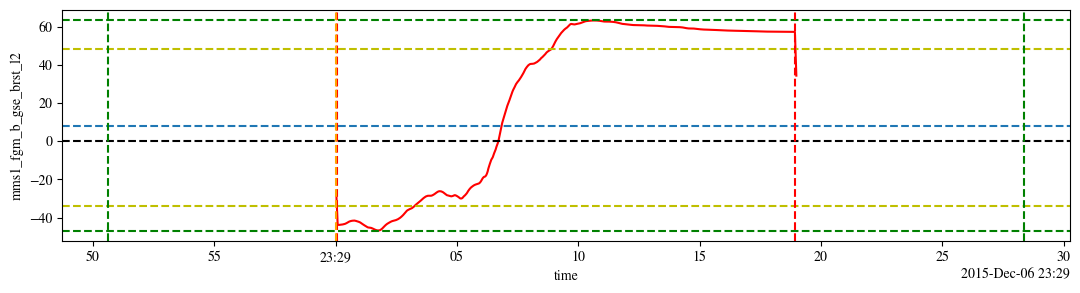

In [245]:
def convolve(data):
    return np.convolve(data, np.ones(5)/5, mode='same')

MID = xr.apply_ufunc(convolve,lmn_b.sel(LMN=0,time=slice(del3,del4)))
mini = lmn_b.sel(LMN=0,time=slice(del3,del4)).min().values
maxi = lmn_b.sel(LMN=0,time=slice(del3,del4)).max().values
b = (mini + maxi)/2
a,c = 0.88*(maxi-b),.88*(mini+b)
t_cs = (MID.time.isel(time=np.where(MID >=a)[0][-1])-MID.time.isel(time=np.where(MID <= c)[0][0]))/np.timedelta64(1, 's')

MID.plot(figsize=(13,3),c='r')
plt.axhline(y=b,ls='--')
plt.axhline(y=maxi,c='g',ls='--')

plt.axhline(y=mini,c='g',ls='--')
plt.axhline(y=0,c='k',ls='--')
plt.axhline(y=a,c='y',ls='--')
plt.axhline(y=c,c='y',ls='--')
plt.axvline(x=MID.time.isel(time=np.where(MID >= a)[0][-1]).values,c='red',ls='--')
plt.axvline(x=MID.time.isel(time=np.where(MID <= c)[0][0]).values,c='red',ls='--') 

plt.axvline(x=MID.time.isel(time=np.where(MID <= 0)[0][0]).values,c='Orange',ls='--') # current sheet crossing

plt.axvline(x=(MID.time.isel(time=np.where(MID >=a)[0][-1])+np.timedelta64(int(t_cs/2*1e9),'ns')).values,c='g',ls='--')
plt.axvline(x=(MID.time.isel(time=np.where(MID <=c)[0][0])-np.timedelta64(int(t_cs/2*1e9),'ns')).values,c='g',ls='--')